# R21 Covariate Randomise Effects

Inspect the covariate-adjusted randomise results. C3/C4 test the blink or pupil covariate effects after including mean FD as the adjustment covariate and are visualized as scatterplots. C1/C2 test adjusted main effects and are visualized as four-condition bar plots when the compiler has exported condition-level ROI values.


## 1. Verify notebook dependencies

Launch this notebook with `bash notebooks/run_covariate_randomise_notebook.sh`. It only needs the tracked covariate randomise summary files, not the large Linux-only dual-regression folders.

In [1]:
from pathlib import Path
import importlib.util

def find_project_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / 'code' / 'check_covariate_randomise_results.py').is_file():
            return candidate
    raise FileNotFoundError('Start Jupyter from the r21-rest repository or one of its subdirectories.')

PROJECT_ROOT = find_project_root()
required_imports = ('matplotlib', 'nibabel', 'nilearn', 'numpy', 'pandas', 'scipy')
missing = [name for name in required_imports if importlib.util.find_spec(name) is None]
if missing:
    raise RuntimeError('Missing packages: ' + ', '.join(missing) + '. Relaunch with notebooks/run_covariate_randomise_notebook.sh')
print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/tug87422/github/r21-rest


## 2. Load C3/C4 covariate rows

FSL corrected-p images store `1-p`, so `peak_corrp > 0.95` corresponds to corrected `p < 0.05`. This first audit focuses on C3/C4, the covariate-effect tests. C1/C2 main effects are handled in later sections.


In [2]:
from io import BytesIO

import matplotlib.pyplot as plt
import nibabel as nib
from nilearn import datasets, image, plotting
import numpy as np
import pandas as pd
from scipy import stats
from IPython.display import display, Markdown, Image as IPyImage

CORRP_THRESHOLD = 0.95


def display_figure(fig, dpi=140):
    buffer = BytesIO()
    fig.savefig(buffer, format='png', dpi=dpi, bbox_inches='tight')
    buffer.seek(0)
    display(IPyImage(data=buffer.getvalue()))
    plt.close(fig)
SUMMARY = PROJECT_ROOT / 'derivatives' / 'fsl' / 'covariate_randomise_summary' / 'task-rest_covariate-randomise_peak_summary.tsv'
if not SUMMARY.is_file():
    raise FileNotFoundError(SUMMARY)

summary = pd.read_csv(SUMMARY, sep='\t', dtype=str, keep_default_na=False)
summary['peak_corrp_num'] = pd.to_numeric(summary['peak_corrp'], errors='coerce')
summary['corrected_p'] = 1.0 - summary['peak_corrp_num']
if 'condition_values_tsv' not in summary.columns:
    summary['condition_values_tsv'] = ''
summary['has_roi_values'] = summary['roi_values_tsv'].str.strip().ne('')
summary['has_condition_values'] = summary['condition_values_tsv'].str.strip().ne('')

covariate_rows = summary[
    summary['design_contrast'].isin(['C3', 'C4'])
    & summary['inference'].eq('cluster-extent')
].copy()
covariate_rows['effect_label'] = (
    covariate_rows['model_label'].str.replace('cov-fdmean-', '', regex=False).str.title()
    + ' '
    + covariate_rows['design_contrast']
    + ' '
    + covariate_rows['contrast_name']
)

n_significant = int((covariate_rows['peak_corrp_num'] > CORRP_THRESHOLD).sum())
display(Markdown(
    f'Loaded **{len(summary)}** total covariate-randomise rows and **{len(covariate_rows)}** C3/C4 rows. '
    f'Completed C3/C4 rows above `1-p > {CORRP_THRESHOLD}`: **{n_significant}**.'
))

audit_columns = [
    'peak_corrp', 'corrected_p', 'model_label', 'analysis', 'network', 'component',
    'condition_contrast', 'design_contrast', 'contrast_name', 'tested_covariate',
    'expected_participants', 'status', 'roi_values_tsv'
]
display(
    covariate_rows.sort_values('peak_corrp_num', ascending=False)[audit_columns]
    .style.format({'corrected_p': '{:.4f}'})
)

Loaded **96** total covariate-randomise rows and **48** C3/C4 rows. Completed C3/C4 rows above `1-p > 0.95`: **0**.

,peak_corrp,corrected_p,model_label,analysis,network,component,condition_contrast,design_contrast,contrast_name,tested_covariate,expected_participants,status,roi_values_tsv
51,0.9444,0.0556,cov-fdmean-pupil,denoised_dim-00_task-rest,sensorimotor,0022,vlpfc-minus-sham,C4,cov_neg,delta_mean_pupil_area,25,ok,
63,0.9428,0.0572,cov-fdmean-pupil,denoised_dim-20_task-rest,sensorimotor,0003,rtpj-minus-sham,C4,cov_neg,delta_mean_pupil_area,27,ok,
23,0.9388,0.0612,cov-fdmean-blink,denoised_dim-20_task-rest,occipital-pole,0017,both-minus-sham,C4,cov_neg,delta_blink_rate_per_min,27,ok,
19,0.9332,0.0668,cov-fdmean-blink,denoised_dim-20_task-rest,primary-visual-lateral-visual,0006,both-minus-vlpfc,C4,cov_neg,delta_blink_rate_per_min,27,ok,
38,0.9024,0.0976,cov-fdmean-blink,smith09_denoised,sensorimotor,0006,both-minus-sham,C3,cov_pos,delta_blink_rate_per_min,27,ok,
55,0.8766,0.1234,cov-fdmean-pupil,denoised_dim-00_task-rest,dmn,0023,rtpj-minus-vlpfc,C4,cov_neg,delta_mean_pupil_area,25,ok,
43,0.8756,0.1244,cov-fdmean-blink,smith09_denoised,sensorimotor,0006,both-minus-rtpj,C4,cov_neg,delta_blink_rate_per_min,27,ok,
22,0.8514,0.1486,cov-fdmean-blink,denoised_dim-20_task-rest,occipital-pole,0017,both-minus-sham,C3,cov_pos,delta_blink_rate_per_min,27,ok,
46,0.8506,0.1494,cov-fdmean-blink,smith09_denoised,ecn,0008,both-minus-rtpj,C3,cov_pos,delta_blink_rate_per_min,27,ok,
90,0.8452,0.1548,cov-fdmean-pupil,smith09_denoised,sensorimotor,0006,both-minus-rtpj,C3,cov_pos,delta_mean_pupil_area,26,ok,


## 3. C3/C4 corrected-p audit

This plot summarizes the strongest covariate-effect maps. It is not a scatterplot; it is a quick audit of whether any C3/C4 map crossed the corrected threshold and which models came closest.

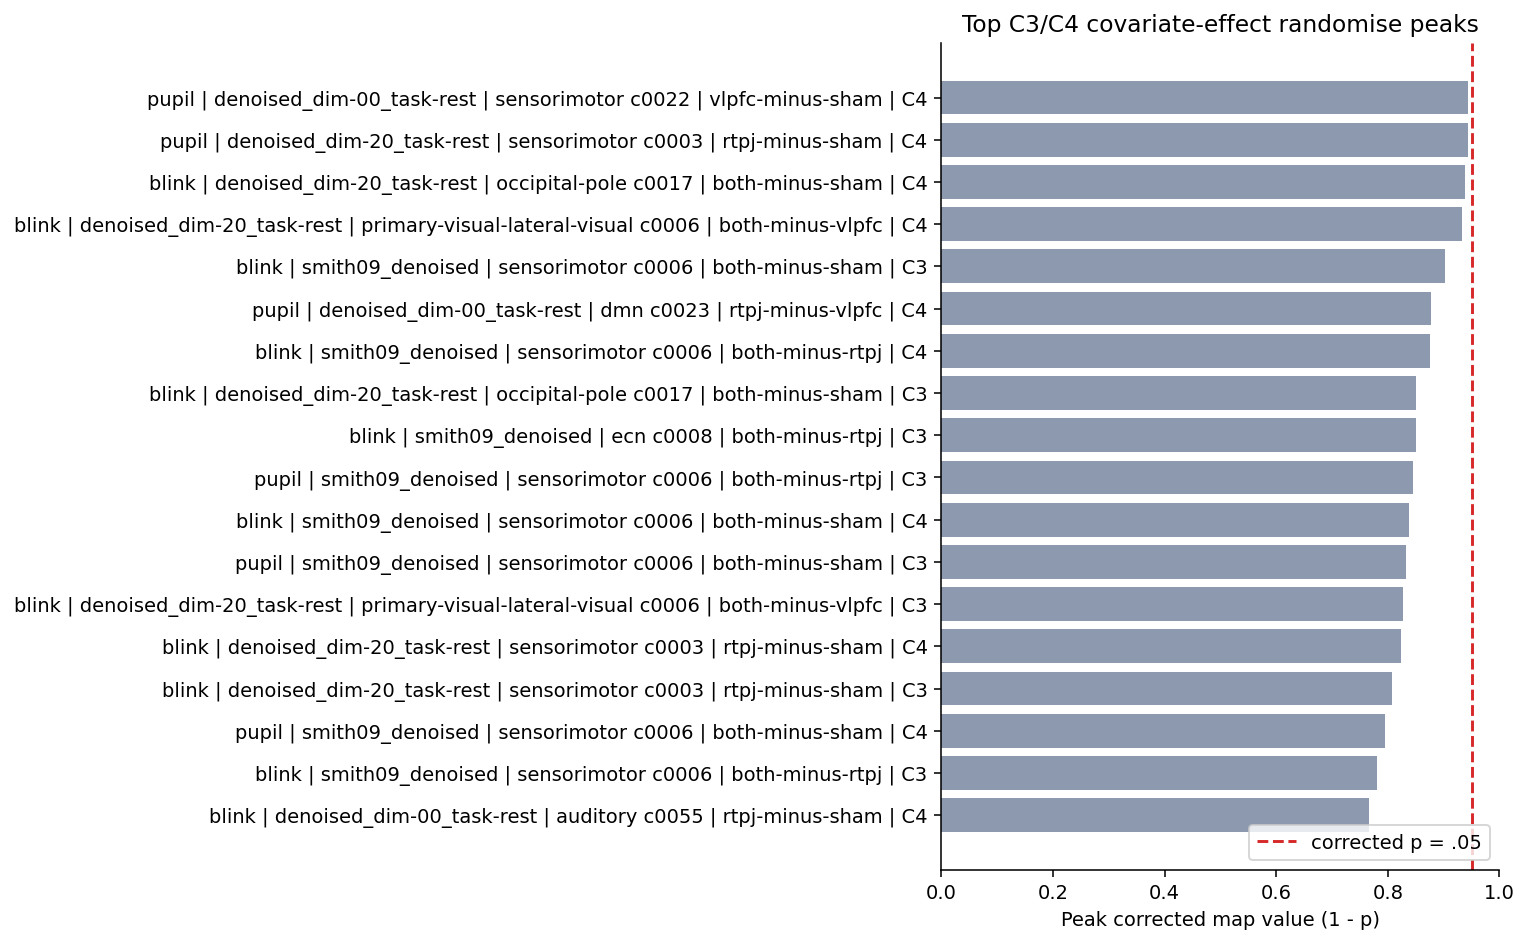

In [3]:
top_n = min(18, len(covariate_rows))
top = covariate_rows.sort_values('peak_corrp_num', ascending=False).head(top_n).iloc[::-1].copy()
labels = (
    top['model_label'].str.replace('cov-fdmean-', '', regex=False)
    + ' | ' + top['analysis']
    + ' | ' + top['network']
    + ' c' + top['component']
    + ' | ' + top['condition_contrast']
    + ' | ' + top['design_contrast']
)
colors = np.where(top['peak_corrp_num'] > CORRP_THRESHOLD, '#0072B2', '#8d99ae')

fig_height = max(5, 0.38 * top_n)
fig, ax = plt.subplots(figsize=(11, fig_height))
ax.barh(labels, top['peak_corrp_num'], color=colors)
ax.axvline(CORRP_THRESHOLD, color='#d62828', linestyle='--', linewidth=1.5, label='corrected p = .05')
ax.set_xlim(0, 1)
ax.set_xlabel('Peak corrected map value (1 - p)')
ax.set_title('Top C3/C4 covariate-effect randomise peaks')
ax.legend(loc='lower right')
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
display_figure(fig)

## 4. C3/C4 scatterplots

Scatterplots use tracked `*_subjectContrast_values.tsv` files. For each significant C3/C4 map, the x axis is the blink or pupil contrast delta and the y axis is the subject-level brain contrast beta extracted from the corrected map ROI. Mean FD remains in the model but is not plotted on the x axis. If no C3/C4 ROI tables exist, the cell reports that explicitly.

In [4]:
COVARIATE_LABELS = {
    'delta_blink_rate_per_min': 'Blink-rate contrast delta (per min)',
    'delta_mean_pupil_area': 'Mean pupil-area contrast delta',
}

def project_path(value):
    path = Path(value)
    return path if path.is_absolute() else PROJECT_ROOT / path

def describe_row(row):
    model = row['model_label'].replace('cov-fdmean-', '').title()
    return (
        f"{model}: {row['analysis']} {row['network']} comp {row['component']} | "
        f"{row['condition_contrast']} | {row['design_contrast']} {row['contrast_name']}"
    )

def plot_covariate_scatter(row):
    values_path = project_path(row['roi_values_tsv'])
    values = pd.read_csv(values_path, sep='\t', dtype=str, keep_default_na=False)
    x_col = row['tested_covariate']
    y_col = 'subject_contrast_beta'
    if x_col not in values:
        raise KeyError(f'{x_col} missing from {values_path}')
    values[x_col] = pd.to_numeric(values[x_col], errors='coerce')
    values[y_col] = pd.to_numeric(values[y_col], errors='coerce')
    values = values.dropna(subset=[x_col, y_col]).copy()
    if len(values) < 3:
        raise ValueError(f'Not enough complete rows for {values_path}')

    pearson = stats.pearsonr(values[x_col], values[y_col])
    spearman = stats.spearmanr(values[x_col], values[y_col])
    slope, intercept, r_value, p_value, stderr = stats.linregress(values[x_col], values[y_col])
    x_line = np.linspace(values[x_col].min(), values[x_col].max(), 100)
    y_line = intercept + slope * x_line

    fig, ax = plt.subplots(figsize=(6.8, 5.2))
    ax.scatter(values[x_col], values[y_col], s=42, color='#0072B2', alpha=0.82, edgecolor='white', linewidth=0.6)
    ax.plot(x_line, y_line, color='#d62828', linewidth=2)
    ax.axhline(0, color='0.75', linewidth=1)
    ax.axvline(0, color='0.75', linewidth=1)
    ax.set_xlabel(COVARIATE_LABELS.get(x_col, x_col))
    ax.set_ylabel('Brain contrast beta in corrected ROI')
    ax.set_title(describe_row(row), fontsize=10)
    ax.text(
        0.02, 0.98,
        f"n = {len(values)}\nPearson r = {pearson.statistic:.2f}, p = {pearson.pvalue:.3g}\n"
        f"Spearman rho = {spearman.statistic:.2f}, p = {spearman.pvalue:.3g}",
        transform=ax.transAxes,
        va='top',
        ha='left',
        bbox={'boxstyle': 'round,pad=0.3', 'facecolor': 'white', 'edgecolor': '0.82'},
    )
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)
    plt.tight_layout()
    display_figure(fig)
    return values

scatter_rows = covariate_rows[covariate_rows['roi_values_tsv'].str.strip().ne('')].copy()
if scatter_rows.empty:
    display(Markdown(
        '**No C3/C4 scatterplots are currently available.** The covariate randomise compiler only wrote ROI-value TSVs for maps with `1-p > 0.95`, and no C3/C4 maps crossed that corrected threshold in this run.'
    ))
    display(Markdown('Closest C3/C4 peaks are shown below for review.'))
    display(covariate_rows.sort_values('peak_corrp_num', ascending=False).head(12)[audit_columns].style.format({'corrected_p': '{:.4f}'}))
else:
    for _, row in scatter_rows.sort_values('peak_corrp_num', ascending=False).iterrows():
        display(Markdown(f"### {describe_row(row)}"))
        plot_covariate_scatter(row)

**No C3/C4 scatterplots are currently available.** The covariate randomise compiler only wrote ROI-value TSVs for maps with `1-p > 0.95`, and no C3/C4 maps crossed that corrected threshold in this run.

Closest C3/C4 peaks are shown below for review.

,peak_corrp,corrected_p,model_label,analysis,network,component,condition_contrast,design_contrast,contrast_name,tested_covariate,expected_participants,status,roi_values_tsv
51,0.9444,0.0556,cov-fdmean-pupil,denoised_dim-00_task-rest,sensorimotor,0022,vlpfc-minus-sham,C4,cov_neg,delta_mean_pupil_area,25,ok,
63,0.9428,0.0572,cov-fdmean-pupil,denoised_dim-20_task-rest,sensorimotor,0003,rtpj-minus-sham,C4,cov_neg,delta_mean_pupil_area,27,ok,
23,0.9388,0.0612,cov-fdmean-blink,denoised_dim-20_task-rest,occipital-pole,0017,both-minus-sham,C4,cov_neg,delta_blink_rate_per_min,27,ok,
19,0.9332,0.0668,cov-fdmean-blink,denoised_dim-20_task-rest,primary-visual-lateral-visual,0006,both-minus-vlpfc,C4,cov_neg,delta_blink_rate_per_min,27,ok,
38,0.9024,0.0976,cov-fdmean-blink,smith09_denoised,sensorimotor,0006,both-minus-sham,C3,cov_pos,delta_blink_rate_per_min,27,ok,
55,0.8766,0.1234,cov-fdmean-pupil,denoised_dim-00_task-rest,dmn,0023,rtpj-minus-vlpfc,C4,cov_neg,delta_mean_pupil_area,25,ok,
43,0.8756,0.1244,cov-fdmean-blink,smith09_denoised,sensorimotor,0006,both-minus-rtpj,C4,cov_neg,delta_blink_rate_per_min,27,ok,
22,0.8514,0.1486,cov-fdmean-blink,denoised_dim-20_task-rest,occipital-pole,0017,both-minus-sham,C3,cov_pos,delta_blink_rate_per_min,27,ok,
46,0.8506,0.1494,cov-fdmean-blink,smith09_denoised,ecn,0008,both-minus-rtpj,C3,cov_pos,delta_blink_rate_per_min,27,ok,
90,0.8452,0.1548,cov-fdmean-pupil,smith09_denoised,sensorimotor,0006,both-minus-rtpj,C3,cov_pos,delta_mean_pupil_area,26,ok,


## 5. C1/C2 main-effect robustness

C1/C2 are the adjusted main-effect tests. This table compares the original significant cluster-extent results against the corresponding covariate-adjusted C1/C2 rows from the blink and pupil models. A result is marked robust when the covariate-adjusted peak still exceeds `1-p > 0.95`.


In [5]:
ORIGINAL_SUMMARIES = [
    PROJECT_ROOT / 'derivatives' / 'fsl' / 'randomise_summary' / 'task-rest_randomise_peak_summary.tsv',
    PROJECT_ROOT / 'derivatives' / 'fsl' / 'randomise_summary' / 'task-rest_desc-SecondaryNetworks_randomise_peak_summary.tsv',
]

original_tables = []
for path in ORIGINAL_SUMMARIES:
    if path.is_file():
        table = pd.read_csv(path, sep='\t', dtype=str, keep_default_na=False)
        table['source_summary'] = path.name
        original_tables.append(table)
if not original_tables:
    raise FileNotFoundError('No original randomise summary tables were found.')
original = pd.concat(original_tables, ignore_index=True)
original['peak_corrp_num'] = pd.to_numeric(original['peak_corrp'], errors='coerce')
original['corrected_p'] = 1.0 - original['peak_corrp_num']

original_sig = original[
    original['inference'].eq('cluster-extent')
    & original['status'].eq('ok')
    & original['peak_gt_threshold'].eq('true')
    & original['design_contrast'].isin(['C1', 'C2'])
].copy()

def analysis_key(value):
    value = str(value)
    if value in {'0', '20', 'smith09'}:
        return value
    if 'dim-00' in value:
        return '0'
    if 'dim-20' in value:
        return '20'
    if 'smith09' in value:
        return 'smith09'
    return value

def component_key(value):
    return str(int(value))

for table in (original_sig, summary):
    table['analysis_key'] = table['analysis'].map(analysis_key)
    table['component_key'] = table['component'].map(component_key)
    table['main_key'] = list(zip(
        table['analysis_key'], table['network'], table['component_key'],
        table['condition_contrast'], table['design_contrast']
    ))

main_rows = summary[
    summary['design_contrast'].isin(['C1', 'C2'])
    & summary['inference'].eq('cluster-extent')
].copy()
main_rows['peak_corrp_num'] = pd.to_numeric(main_rows['peak_corrp'], errors='coerce')
main_rows['corrected_p'] = 1.0 - main_rows['peak_corrp_num']
main_rows['analysis_key'] = main_rows['analysis'].map(analysis_key)
main_rows['component_key'] = main_rows['component'].map(component_key)
main_rows['main_key'] = list(zip(
    main_rows['analysis_key'], main_rows['network'], main_rows['component_key'],
    main_rows['condition_contrast'], main_rows['design_contrast']
))

covariate_lookup = {
    (row['main_key'], row['model_label']): row
    for _, row in main_rows.iterrows()
}

records = []
for _, original_row in original_sig.sort_values('peak_corrp_num', ascending=False).iterrows():
    key = original_row['main_key']
    blink = covariate_lookup.get((key, 'cov-fdmean-blink'))
    pupil = covariate_lookup.get((key, 'cov-fdmean-pupil'))
    record = {
        'analysis': original_row['analysis'],
        'network': original_row['network'],
        'component': original_row['component'],
        'condition_contrast': original_row['condition_contrast'],
        'design_contrast': original_row['design_contrast'],
        'direction': original_row['direction'],
        'original_peak': original_row['peak_corrp_num'],
        'original_p': original_row['corrected_p'],
        'blink_peak': np.nan if blink is None else blink['peak_corrp_num'],
        'blink_p': np.nan if blink is None else blink['corrected_p'],
        'blink_n': '' if blink is None else blink['expected_participants'],
        'blink_robust': False if blink is None else bool(blink['peak_corrp_num'] > CORRP_THRESHOLD),
        'pupil_peak': np.nan if pupil is None else pupil['peak_corrp_num'],
        'pupil_p': np.nan if pupil is None else pupil['corrected_p'],
        'pupil_n': '' if pupil is None else pupil['expected_participants'],
        'pupil_robust': False if pupil is None else bool(pupil['peak_corrp_num'] > CORRP_THRESHOLD),
        'main_key': key,
    }
    record['robust_both_models'] = record['blink_robust'] and record['pupil_robust']
    records.append(record)

robustness = pd.DataFrame.from_records(records)
summary_counts = {
    'original_significant': len(robustness),
    'robust_with_fd_blink': int(robustness['blink_robust'].sum()),
    'robust_with_fd_pupil': int(robustness['pupil_robust'].sum()),
    'robust_in_both_covariate_models': int(robustness['robust_both_models'].sum()),
}
display(Markdown(
    f"Original significant C1/C2 rows: **{summary_counts['original_significant']}**. "
    f"Robust with FD+blink: **{summary_counts['robust_with_fd_blink']}**; "
    f"robust with FD+pupil: **{summary_counts['robust_with_fd_pupil']}**; "
    f"robust in both: **{summary_counts['robust_in_both_covariate_models']}**."
))

robust_columns = [
    'analysis', 'network', 'component', 'condition_contrast', 'design_contrast',
    'original_peak', 'original_p', 'blink_peak', 'blink_p', 'blink_n', 'blink_robust',
    'pupil_peak', 'pupil_p', 'pupil_n', 'pupil_robust', 'robust_both_models'
]
display(
    robustness[robust_columns]
    .style.format({
        'original_peak': '{:.4f}', 'original_p': '{:.4f}',
        'blink_peak': '{:.4f}', 'blink_p': '{:.4f}',
        'pupil_peak': '{:.4f}', 'pupil_p': '{:.4f}',
    }, na_rep='')
)


Original significant C1/C2 rows: **12**. Robust with FD+blink: **10**; robust with FD+pupil: **7**; robust in both: **6**.

,analysis,network,component,condition_contrast,design_contrast,original_peak,original_p,blink_peak,blink_p,blink_n,blink_robust,pupil_peak,pupil_p,pupil_n,pupil_robust,robust_both_models
0,20,occipital-pole,17,both-minus-sham,C2,0.9936,0.0064,0.9968,0.0032,27,True,0.8058,0.1942,26,False,False
1,0,dmn,23,rtpj-minus-vlpfc,C2,0.9934,0.0066,0.9912,0.0088,27,True,0.9638,0.0362,25,True,True
2,smith09,lateral-visual,3,both-minus-vlpfc,C2,0.9914,0.0086,0.9894,0.0106,27,True,0.9898,0.0102,24,True,True
3,smith09,dmn,4,rtpj-minus-vlpfc,C2,0.9844,0.0156,0.9762,0.0238,27,True,0.9826,0.0174,25,True,True
4,20,primary-visual-lateral-visual,6,both-minus-vlpfc,C1,0.9806,0.0194,0.9936,0.0064,27,True,0.9704,0.0296,24,True,True
5,smith09,ecn,8,both-minus-rtpj,C2,0.9800,0.0200,0.9910,0.0090,27,True,0.9298,0.0702,26,False,False
6,smith09,sensorimotor,6,both-minus-rtpj,C1,0.9796,0.0204,0.9998,0.0002,27,True,0.9980,0.0020,26,True,True
7,0,sensorimotor,22,vlpfc-minus-sham,C1,0.9728,0.0272,0.8590,0.1410,27,False,0.9640,0.0360,25,True,False
8,20,sensorimotor,3,rtpj-minus-sham,C1,0.9634,0.0366,0.9740,0.0260,27,True,0.9822,0.0178,27,True,True
9,smith09,lateral-visual,3,rtpj-minus-vlpfc,C2,0.9618,0.0382,0.9564,0.0436,27,True,0.9340,0.0660,25,False,False


## 6. C1/C2 covariate-adjusted brain maps and condition bar plots

C1/C2 main-effect displays use the covariate-adjusted corrected map from `copied_image`, thresholded at `1-p > 0.95`. The four-condition bars use stage-2 beta values extracted from that same covariate-adjusted ROI, with sham, RTPJ, VLPFC, and BOTH means plus SEM. These bars are descriptive because the ROI is selected from the same corrected map. Scatterplots are reserved for C3/C4 covariate-effect tests.


Found **17** covariate-adjusted C1/C2 condition-value tables linked to the original significant set.

,model_label,analysis,network,component,condition_contrast,design_contrast,contrast_name,peak_corrp,expected_participants,copied_image,condition_values_tsv
40,cov-fdmean-blink,smith09_denoised,sensorimotor,0006,both-minus-rtpj,C1,mean_pos,0.9998,27,derivatives/fsl/covariate_randomise_summary/ta...,derivatives/fsl/covariate_randomise_summary/ta...
88,cov-fdmean-pupil,smith09_denoised,sensorimotor,0006,both-minus-rtpj,C1,mean_pos,0.998,26,derivatives/fsl/covariate_randomise_summary/ta...,derivatives/fsl/covariate_randomise_summary/ta...
21,cov-fdmean-blink,denoised_dim-20_task-rest,occipital-pole,0017,both-minus-sham,C2,mean_neg,0.9968,27,derivatives/fsl/covariate_randomise_summary/ta...,derivatives/fsl/covariate_randomise_summary/ta...
16,cov-fdmean-blink,denoised_dim-20_task-rest,primary-visual-lateral-visual,0006,both-minus-vlpfc,C1,mean_pos,0.9936,27,derivatives/fsl/covariate_randomise_summary/ta...,derivatives/fsl/covariate_randomise_summary/ta...
5,cov-fdmean-blink,denoised_dim-00_task-rest,dmn,0023,rtpj-minus-vlpfc,C2,mean_neg,0.9912,27,derivatives/fsl/covariate_randomise_summary/ta...,derivatives/fsl/covariate_randomise_summary/ta...
45,cov-fdmean-blink,smith09_denoised,ecn,0008,both-minus-rtpj,C2,mean_neg,0.991,27,derivatives/fsl/covariate_randomise_summary/ta...,derivatives/fsl/covariate_randomise_summary/ta...
73,cov-fdmean-pupil,smith09_denoised,lateral-visual,0003,both-minus-vlpfc,C2,mean_neg,0.9898,24,derivatives/fsl/covariate_randomise_summary/ta...,derivatives/fsl/covariate_randomise_summary/ta...
25,cov-fdmean-blink,smith09_denoised,lateral-visual,0003,both-minus-vlpfc,C2,mean_neg,0.9894,27,derivatives/fsl/covariate_randomise_summary/ta...,derivatives/fsl/covariate_randomise_summary/ta...
36,cov-fdmean-blink,smith09_denoised,sensorimotor,0006,both-minus-sham,C1,mean_pos,0.9828,27,derivatives/fsl/covariate_randomise_summary/ta...,derivatives/fsl/covariate_randomise_summary/ta...
81,cov-fdmean-pupil,smith09_denoised,dmn,0004,rtpj-minus-vlpfc,C2,mean_neg,0.9826,25,derivatives/fsl/covariate_randomise_summary/ta...,derivatives/fsl/covariate_randomise_summary/ta...


### Blink: smith09_denoised sensorimotor comp 0006 | both-minus-rtpj | C1 mean_pos

Covariate-adjusted brain map: `derivatives/fsl/covariate_randomise_summary/task-rest_space-MNI152NLin6Asym_desc-Smith09DenoisedCovFdmeanBlinkSensorimotorComp0006BothMinusRtpjMeanPosClusterExtentCorrp_stat-corrp_statmap.nii.gz`    
Threshold: `1-p > 0.95`; voxels shown: **47**.

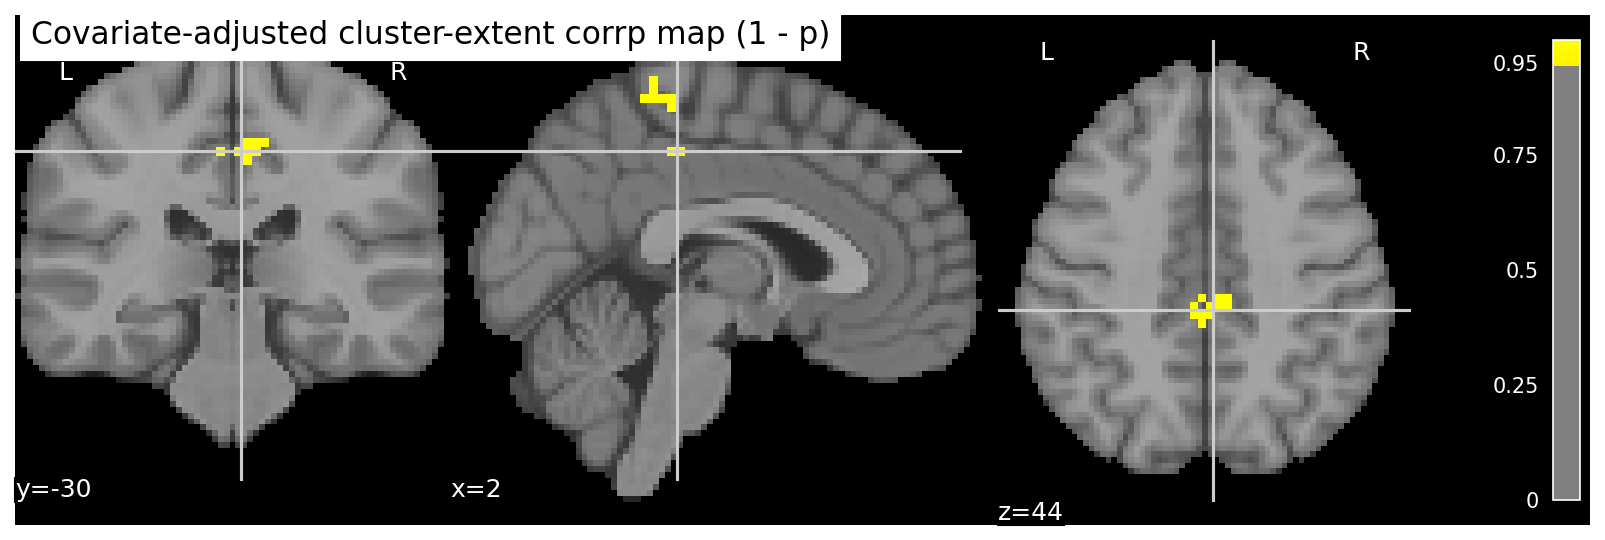

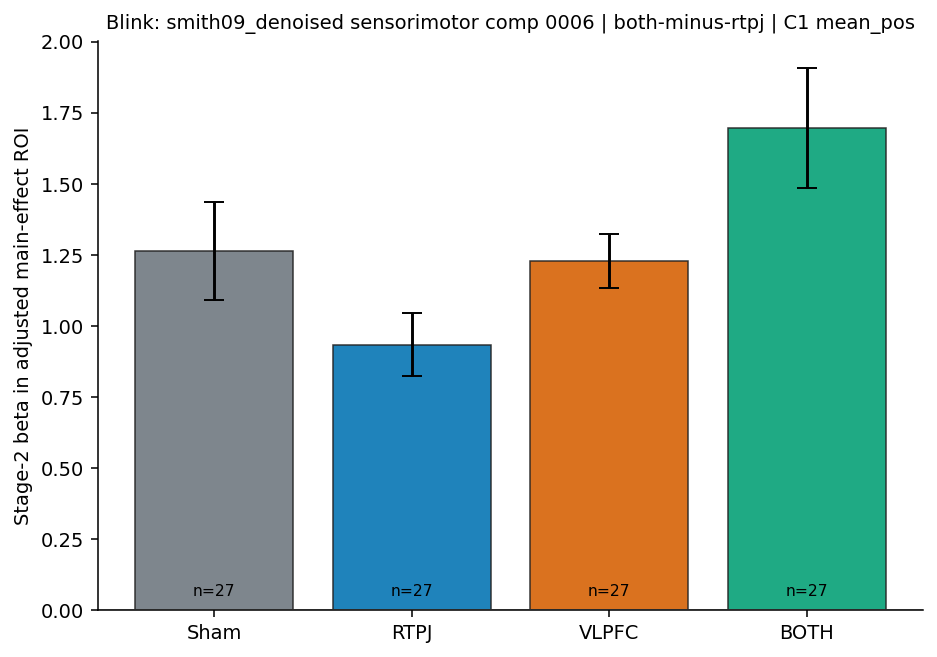

### Pupil: smith09_denoised sensorimotor comp 0006 | both-minus-rtpj | C1 mean_pos

Covariate-adjusted brain map: `derivatives/fsl/covariate_randomise_summary/task-rest_space-MNI152NLin6Asym_desc-Smith09DenoisedCovFdmeanPupilSensorimotorComp0006BothMinusRtpjMeanPosClusterExtentCorrp_stat-corrp_statmap.nii.gz`    
Threshold: `1-p > 0.95`; voxels shown: **47**.

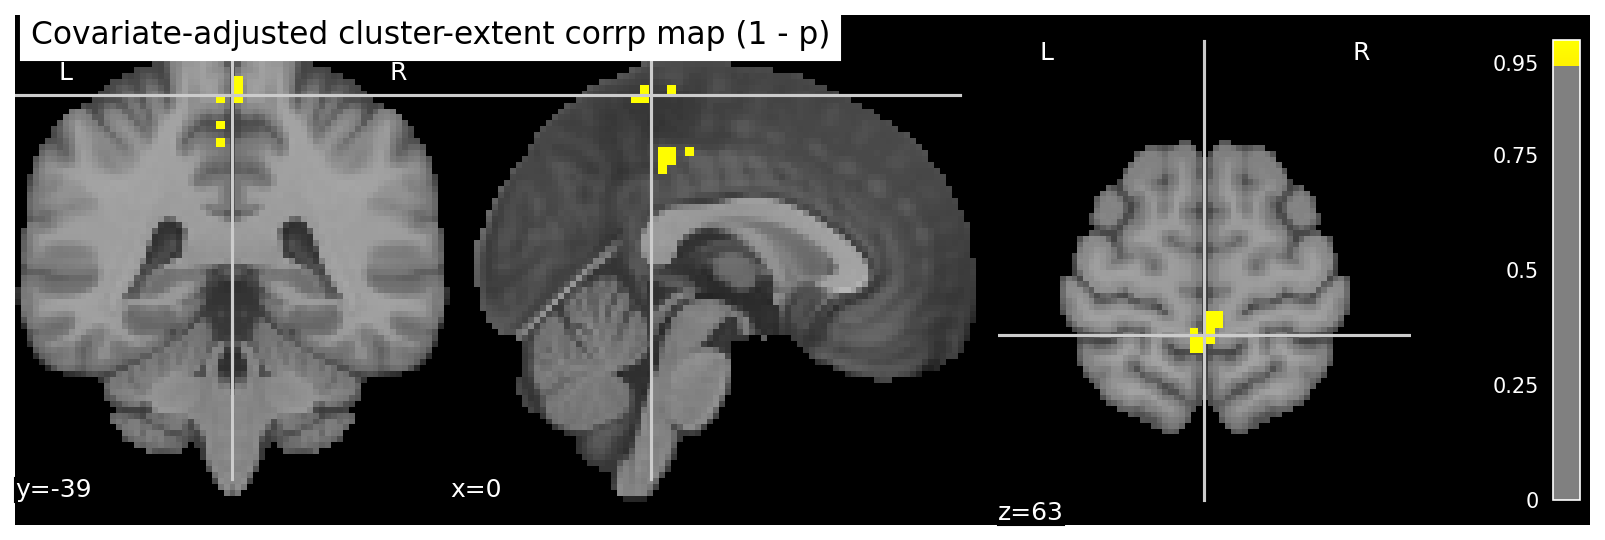

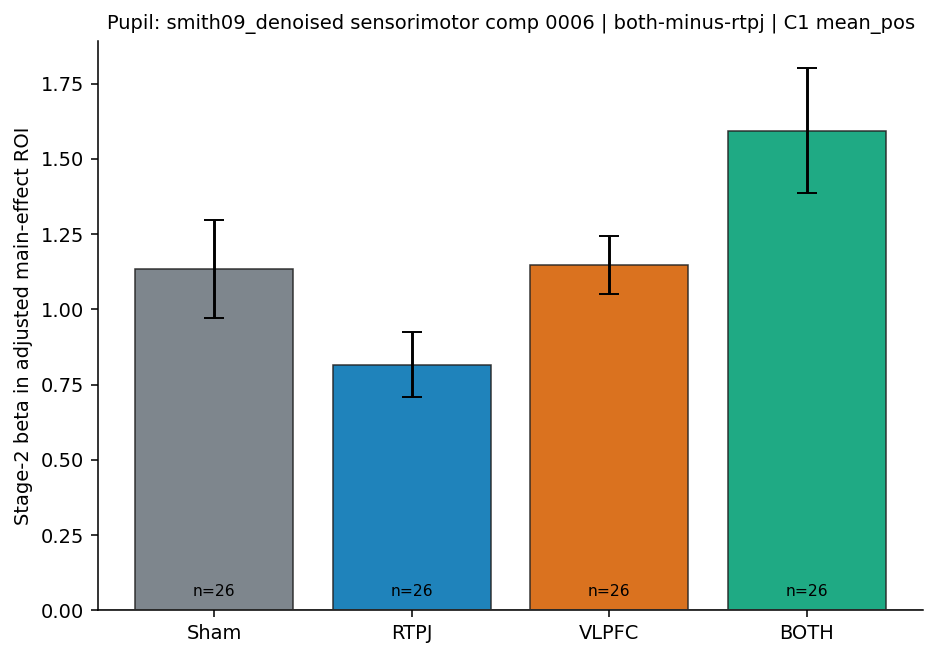

### Blink: denoised_dim-20_task-rest occipital-pole comp 0017 | both-minus-sham | C2 mean_neg

Covariate-adjusted brain map: `derivatives/fsl/covariate_randomise_summary/task-rest_space-MNI152NLin6Asym_desc-DenoisedDim20TaskRestCovFdmeanBlinkOccipitalPoleComp0017BothMinusShamMeanNegClusterExtentCorrp_stat-corrp_statmap.nii.gz`    
Threshold: `1-p > 0.95`; voxels shown: **15**.

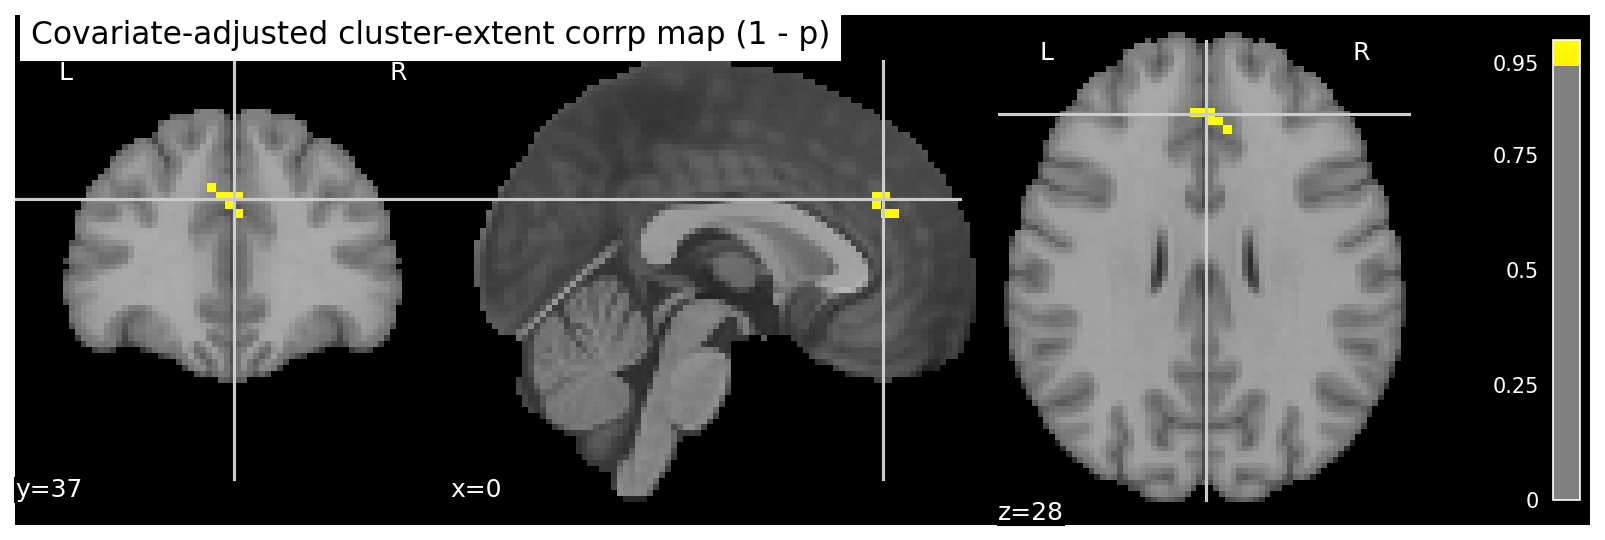

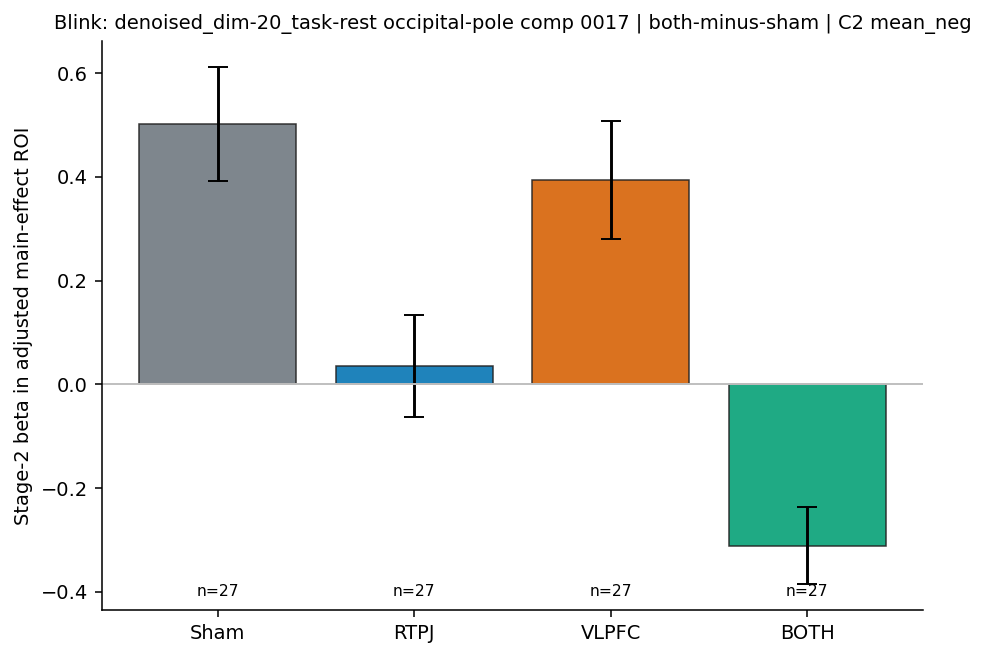

### Blink: denoised_dim-20_task-rest primary-visual-lateral-visual comp 0006 | both-minus-vlpfc | C1 mean_pos

Covariate-adjusted brain map: `derivatives/fsl/covariate_randomise_summary/task-rest_space-MNI152NLin6Asym_desc-DenoisedDim20TaskRestCovFdmeanBlinkPrimaryVisualLateralVisualComp0006BothMinusVlpfcMeanPosClusterExtentCorrp_stat-corrp_statmap.nii.gz`    
Threshold: `1-p > 0.95`; voxels shown: **14**.

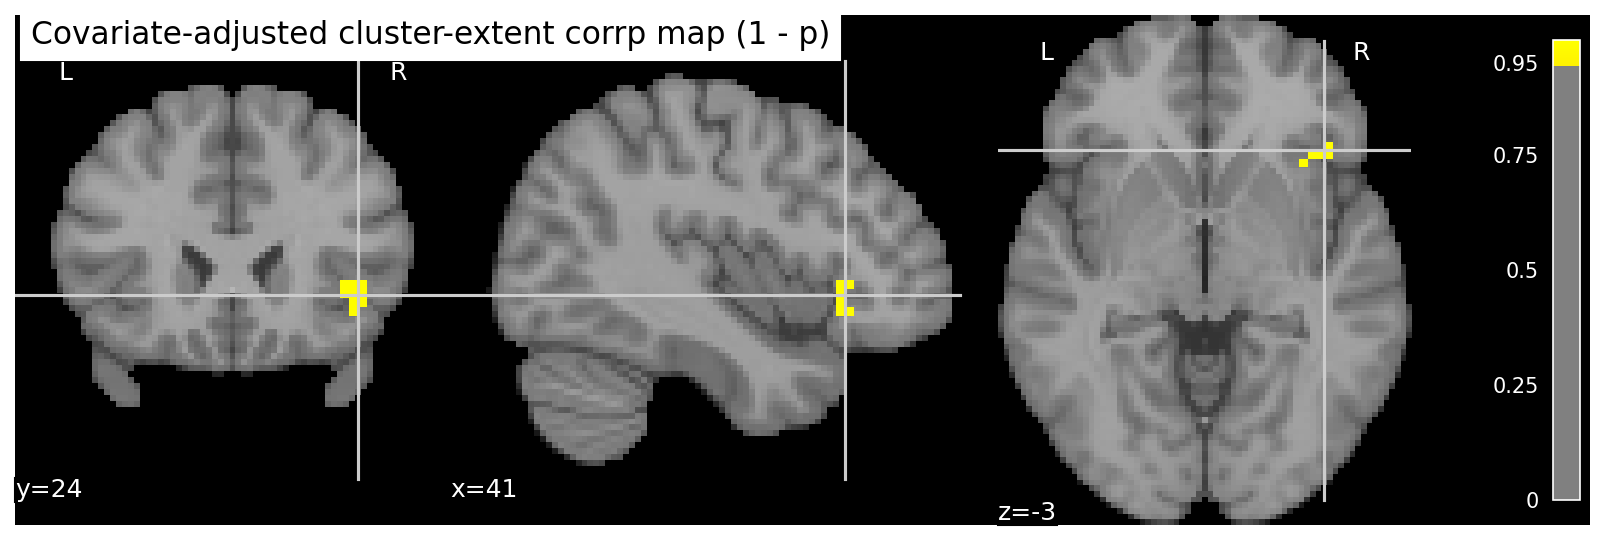

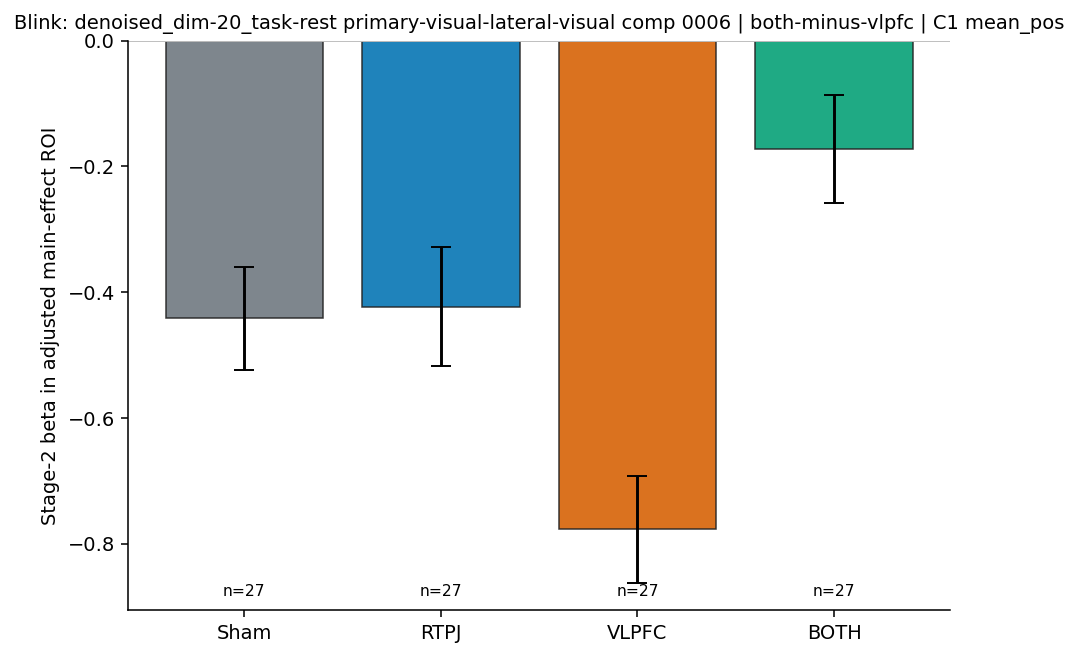

### Blink: denoised_dim-00_task-rest dmn comp 0023 | rtpj-minus-vlpfc | C2 mean_neg

Covariate-adjusted brain map: `derivatives/fsl/covariate_randomise_summary/task-rest_space-MNI152NLin6Asym_desc-DenoisedDim00TaskRestCovFdmeanBlinkDmnComp0023RtpjMinusVlpfcMeanNegClusterExtentCorrp_stat-corrp_statmap.nii.gz`    
Threshold: `1-p > 0.95`; voxels shown: **9**.

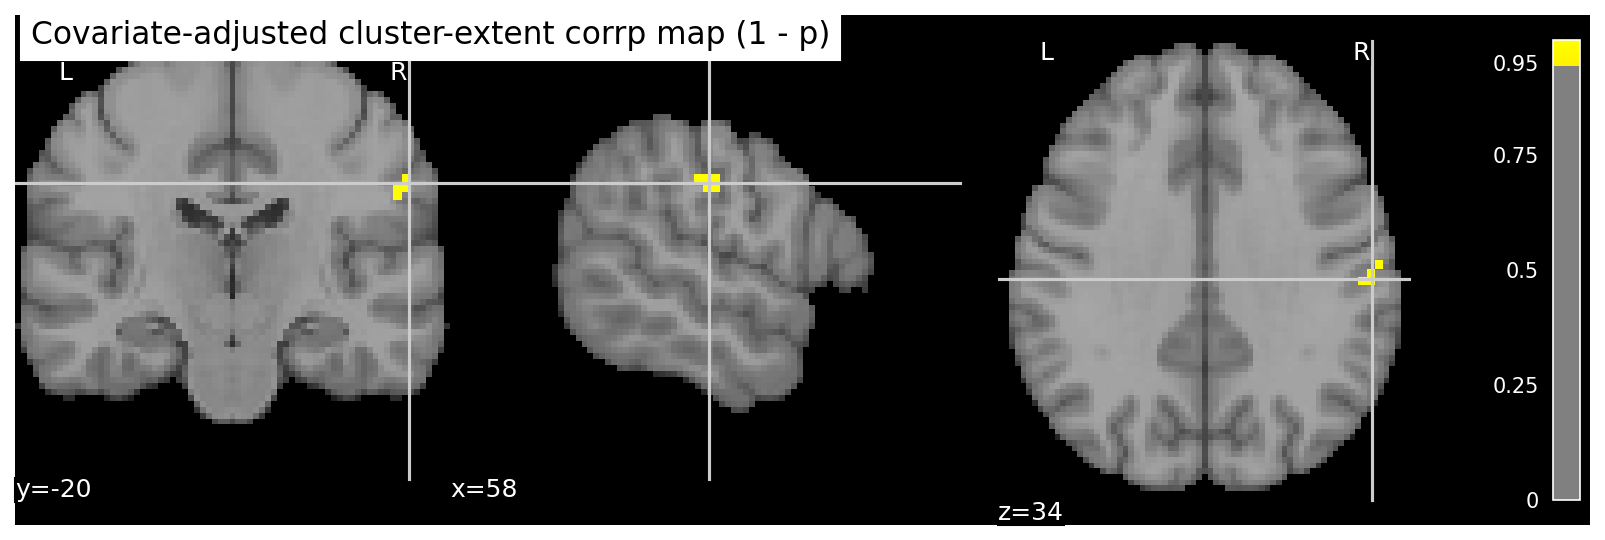

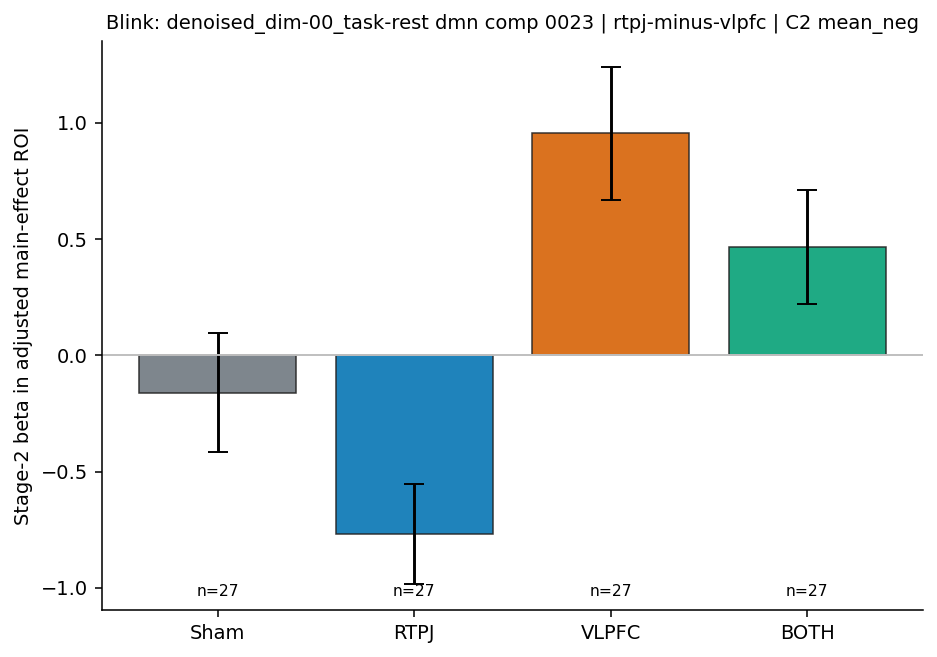

### Blink: smith09_denoised ecn comp 0008 | both-minus-rtpj | C2 mean_neg

Covariate-adjusted brain map: `derivatives/fsl/covariate_randomise_summary/task-rest_space-MNI152NLin6Asym_desc-Smith09DenoisedCovFdmeanBlinkEcnComp0008BothMinusRtpjMeanNegClusterExtentCorrp_stat-corrp_statmap.nii.gz`    
Threshold: `1-p > 0.95`; voxels shown: **19**.

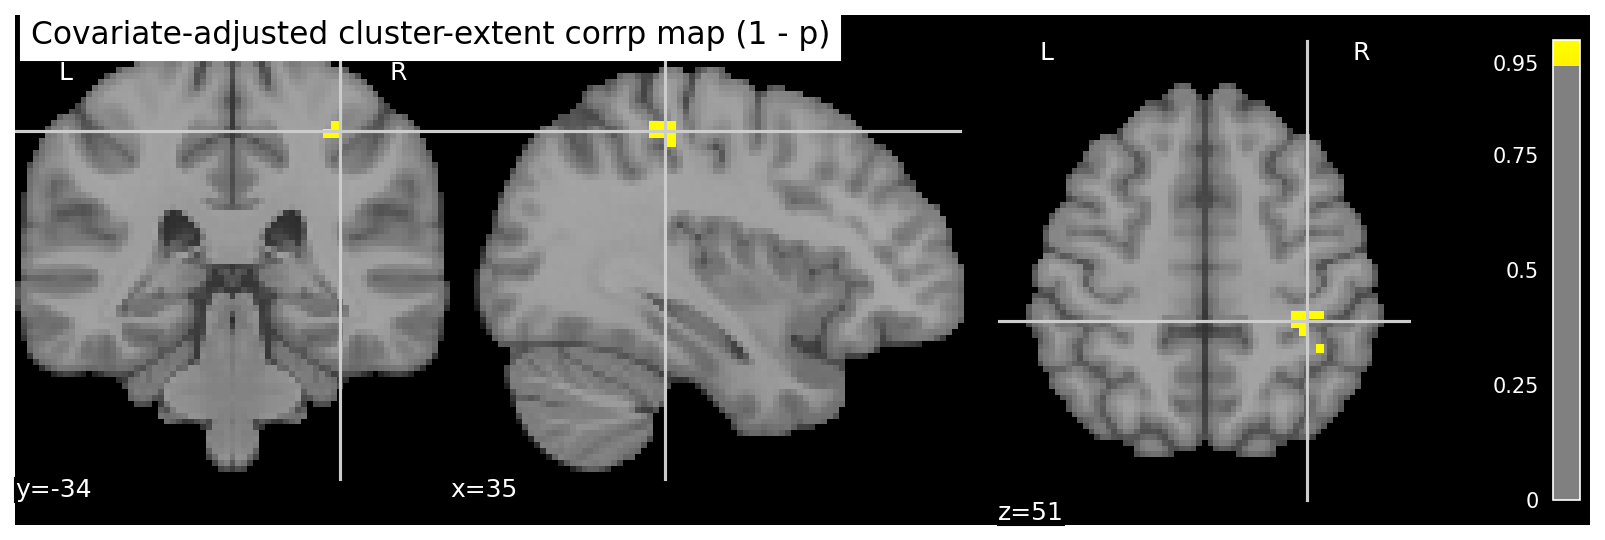

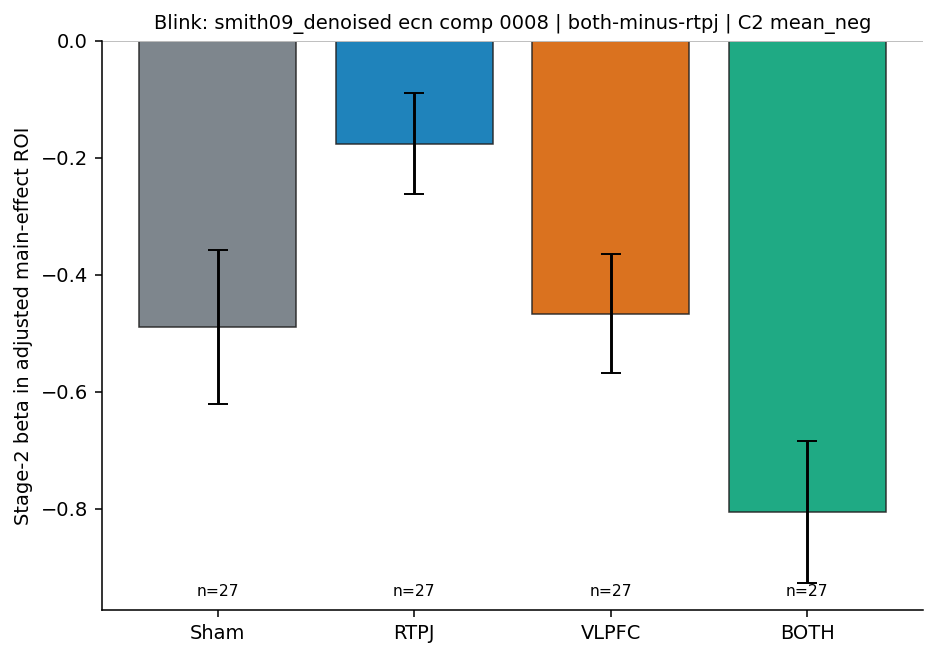

### Pupil: smith09_denoised lateral-visual comp 0003 | both-minus-vlpfc | C2 mean_neg

Covariate-adjusted brain map: `derivatives/fsl/covariate_randomise_summary/task-rest_space-MNI152NLin6Asym_desc-Smith09DenoisedCovFdmeanPupilLateralVisualComp0003BothMinusVlpfcMeanNegClusterExtentCorrp_stat-corrp_statmap.nii.gz`    
Threshold: `1-p > 0.95`; voxels shown: **32**.

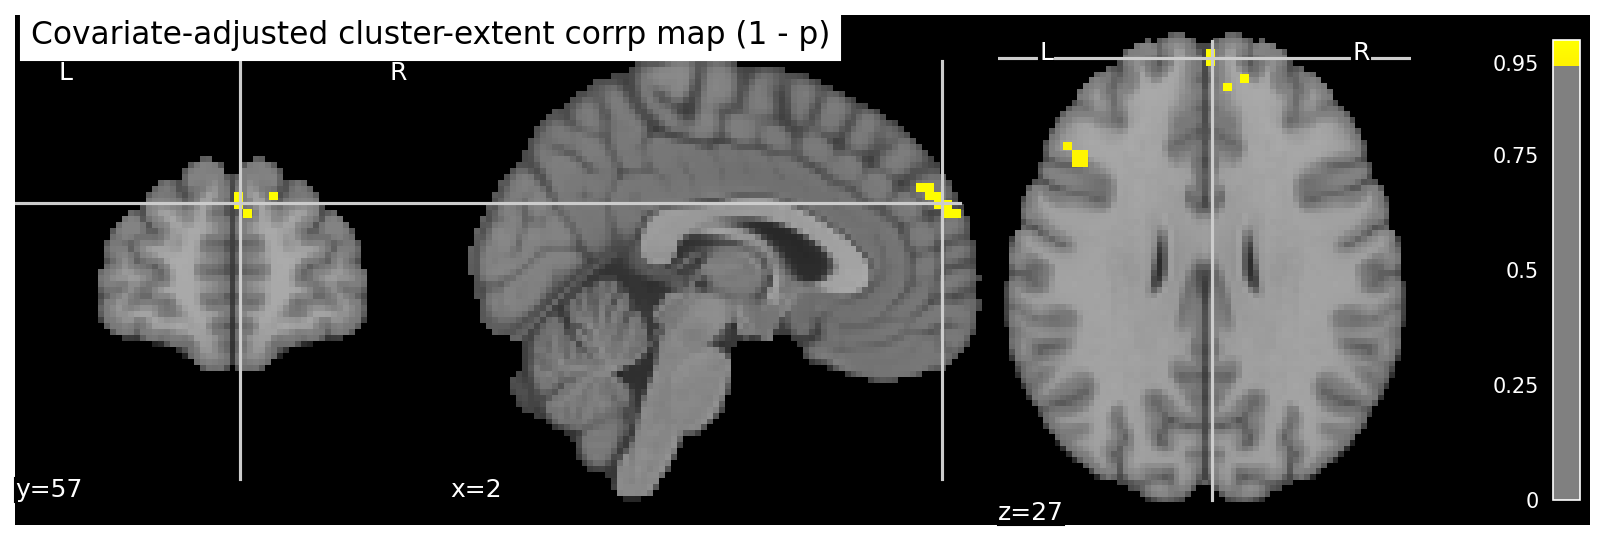

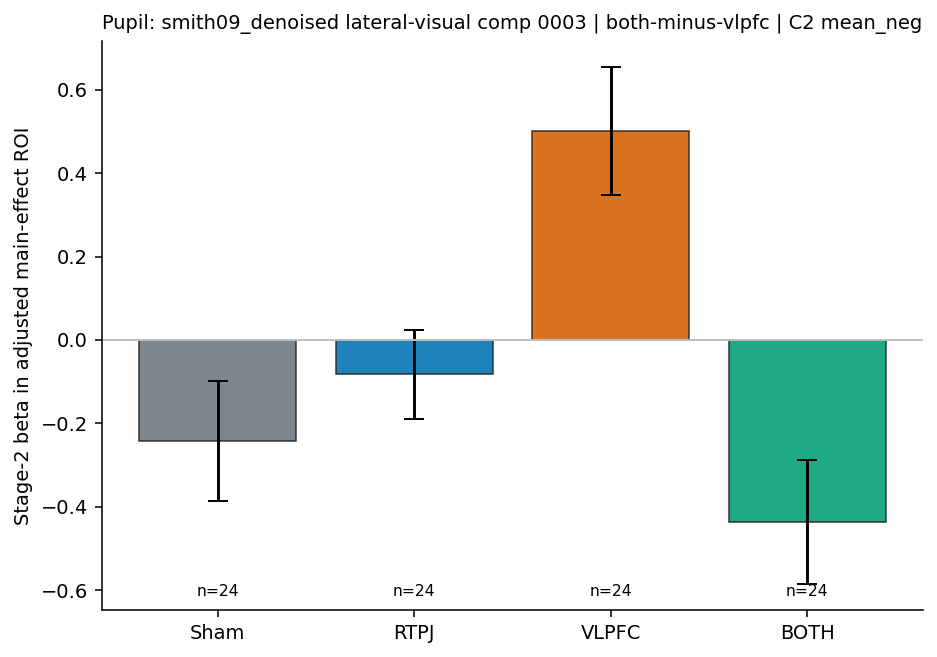

### Blink: smith09_denoised lateral-visual comp 0003 | both-minus-vlpfc | C2 mean_neg

Covariate-adjusted brain map: `derivatives/fsl/covariate_randomise_summary/task-rest_space-MNI152NLin6Asym_desc-Smith09DenoisedCovFdmeanBlinkLateralVisualComp0003BothMinusVlpfcMeanNegClusterExtentCorrp_stat-corrp_statmap.nii.gz`    
Threshold: `1-p > 0.95`; voxels shown: **33**.

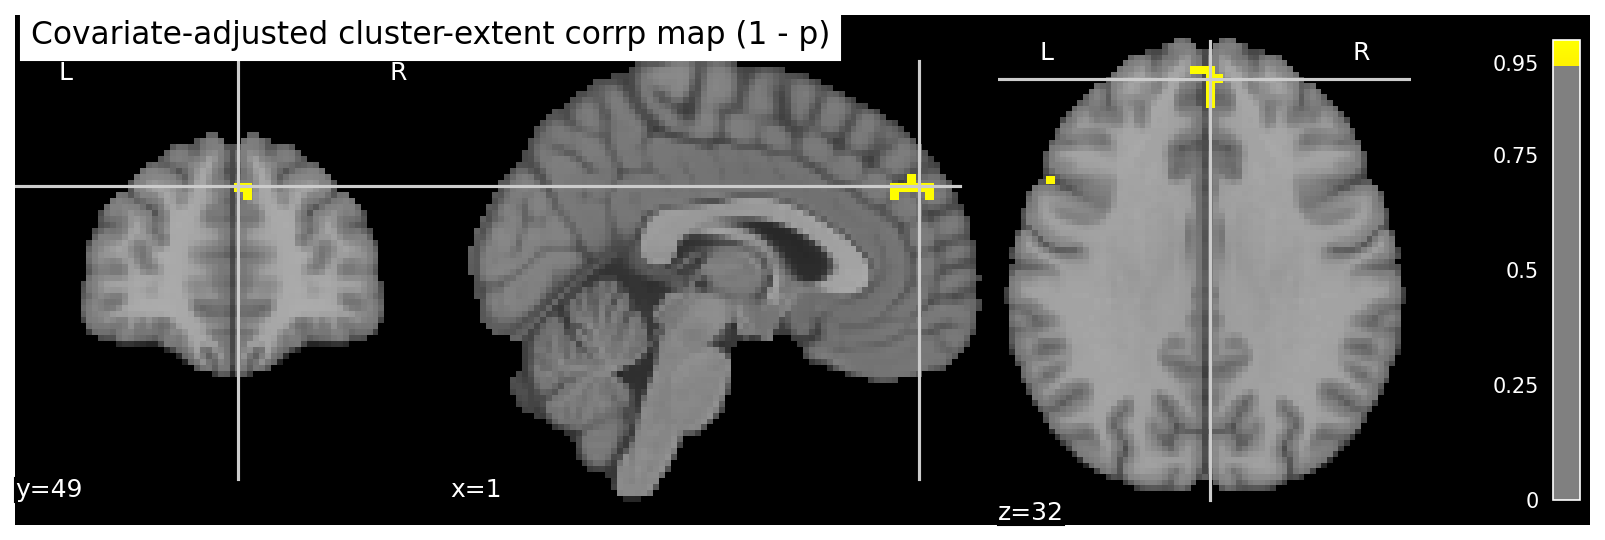

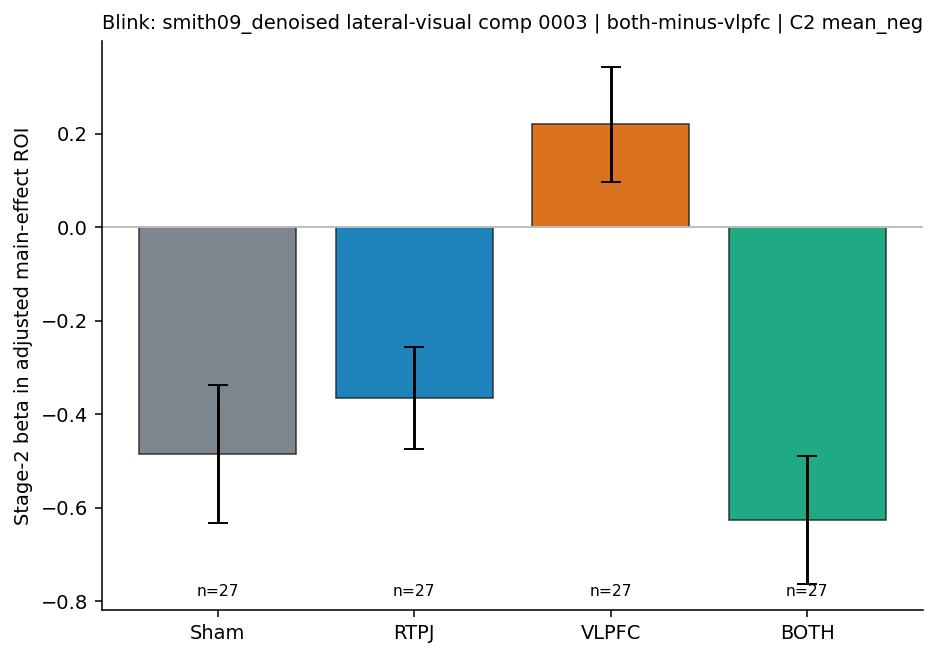

### Blink: smith09_denoised sensorimotor comp 0006 | both-minus-sham | C1 mean_pos

Covariate-adjusted brain map: `derivatives/fsl/covariate_randomise_summary/task-rest_space-MNI152NLin6Asym_desc-Smith09DenoisedCovFdmeanBlinkSensorimotorComp0006BothMinusShamMeanPosClusterExtentCorrp_stat-corrp_statmap.nii.gz`    
Threshold: `1-p > 0.95`; voxels shown: **16**.

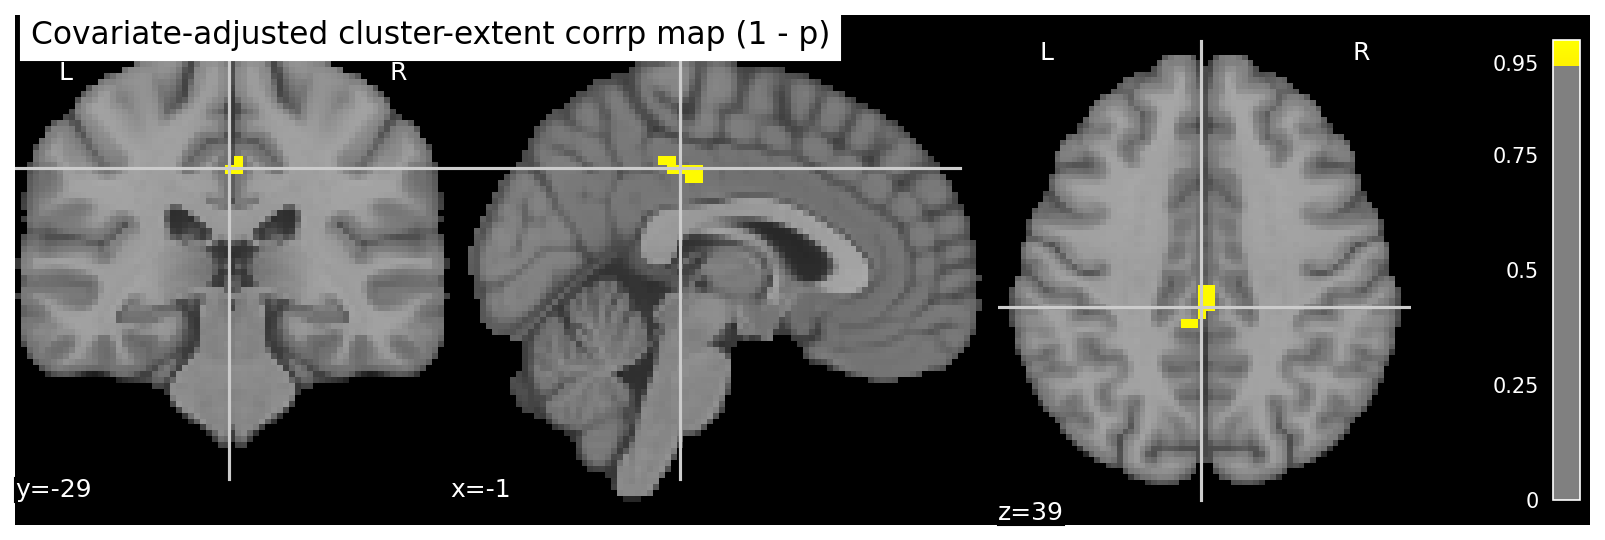

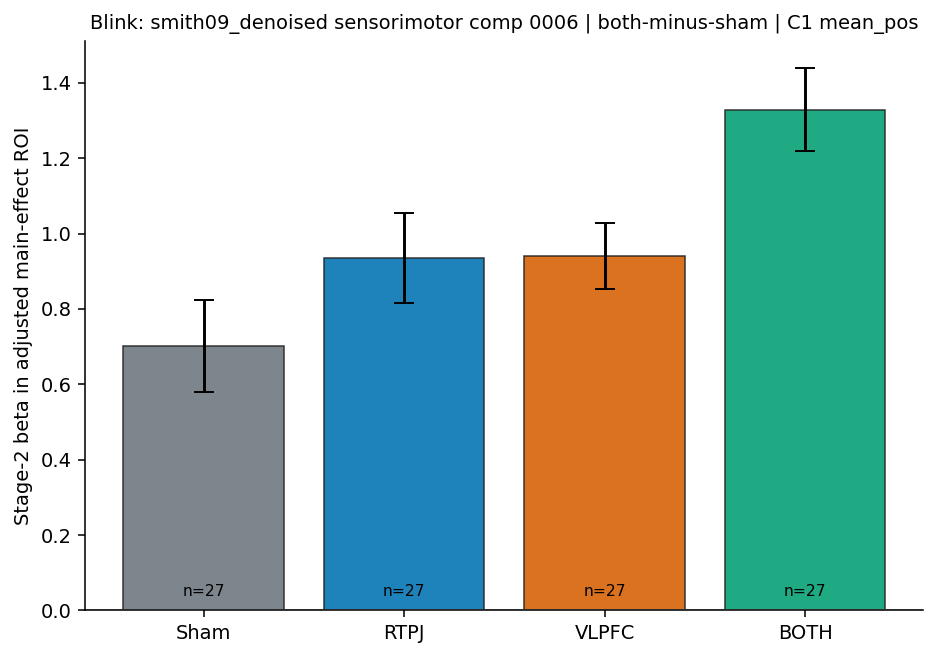

### Pupil: smith09_denoised dmn comp 0004 | rtpj-minus-vlpfc | C2 mean_neg

Covariate-adjusted brain map: `derivatives/fsl/covariate_randomise_summary/task-rest_space-MNI152NLin6Asym_desc-Smith09DenoisedCovFdmeanPupilDmnComp0004RtpjMinusVlpfcMeanNegClusterExtentCorrp_stat-corrp_statmap.nii.gz`    
Threshold: `1-p > 0.95`; voxels shown: **18**.

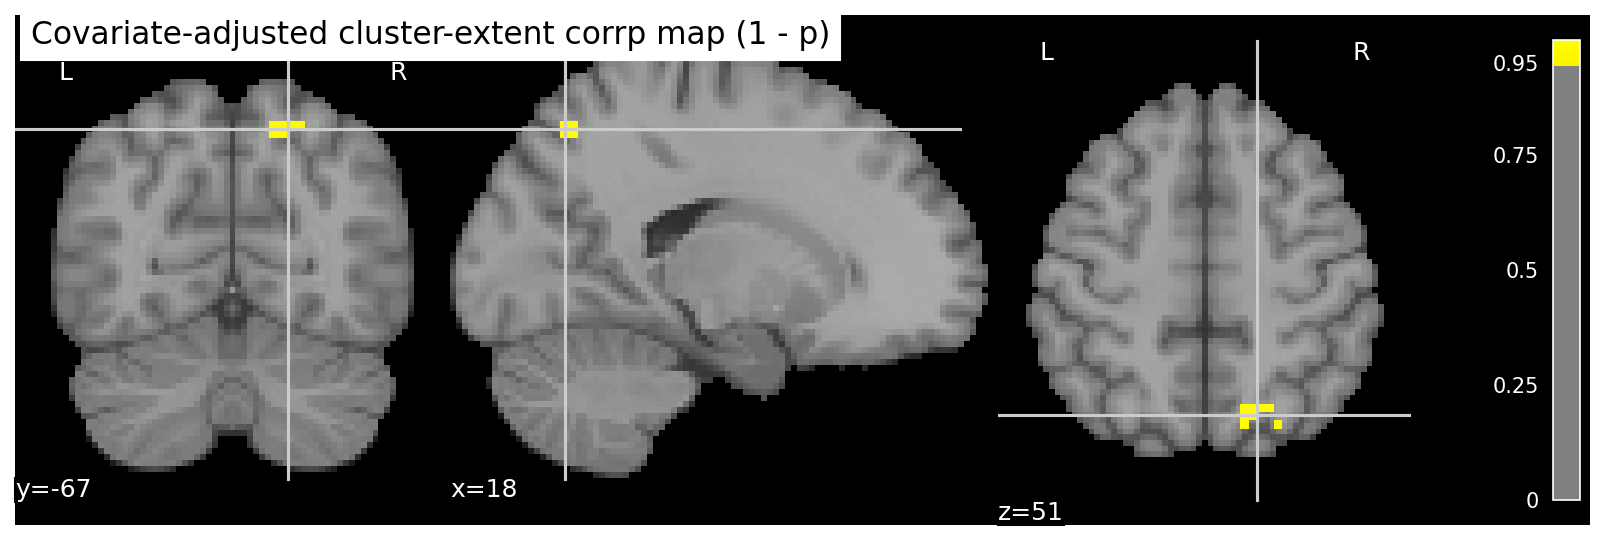

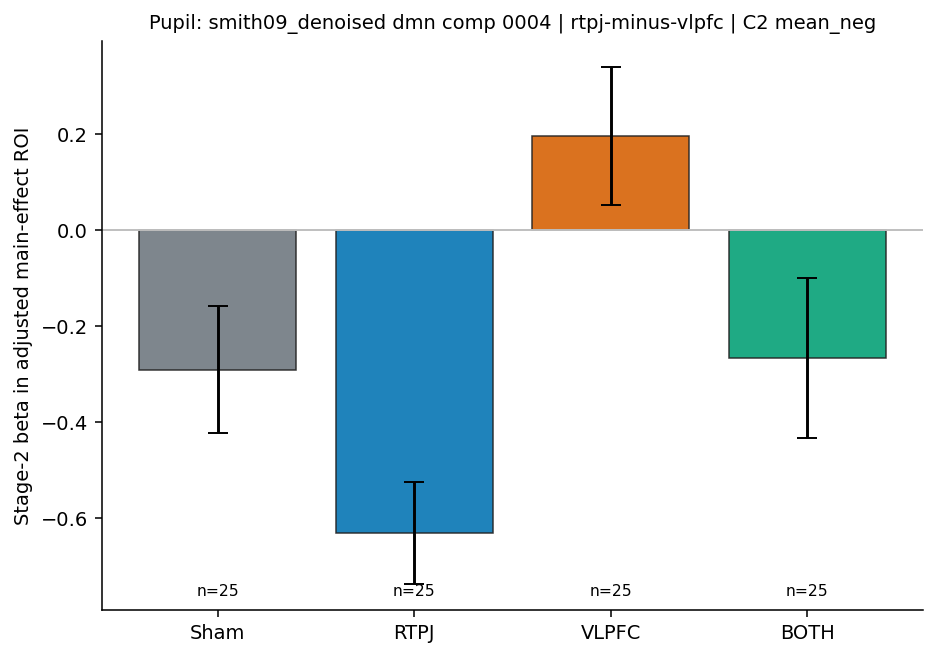

### Pupil: denoised_dim-20_task-rest sensorimotor comp 0003 | rtpj-minus-sham | C1 mean_pos

Covariate-adjusted brain map: `derivatives/fsl/covariate_randomise_summary/task-rest_space-MNI152NLin6Asym_desc-DenoisedDim20TaskRestCovFdmeanPupilSensorimotorComp0003RtpjMinusShamMeanPosClusterExtentCorrp_stat-corrp_statmap.nii.gz`    
Threshold: `1-p > 0.95`; voxels shown: **13**.

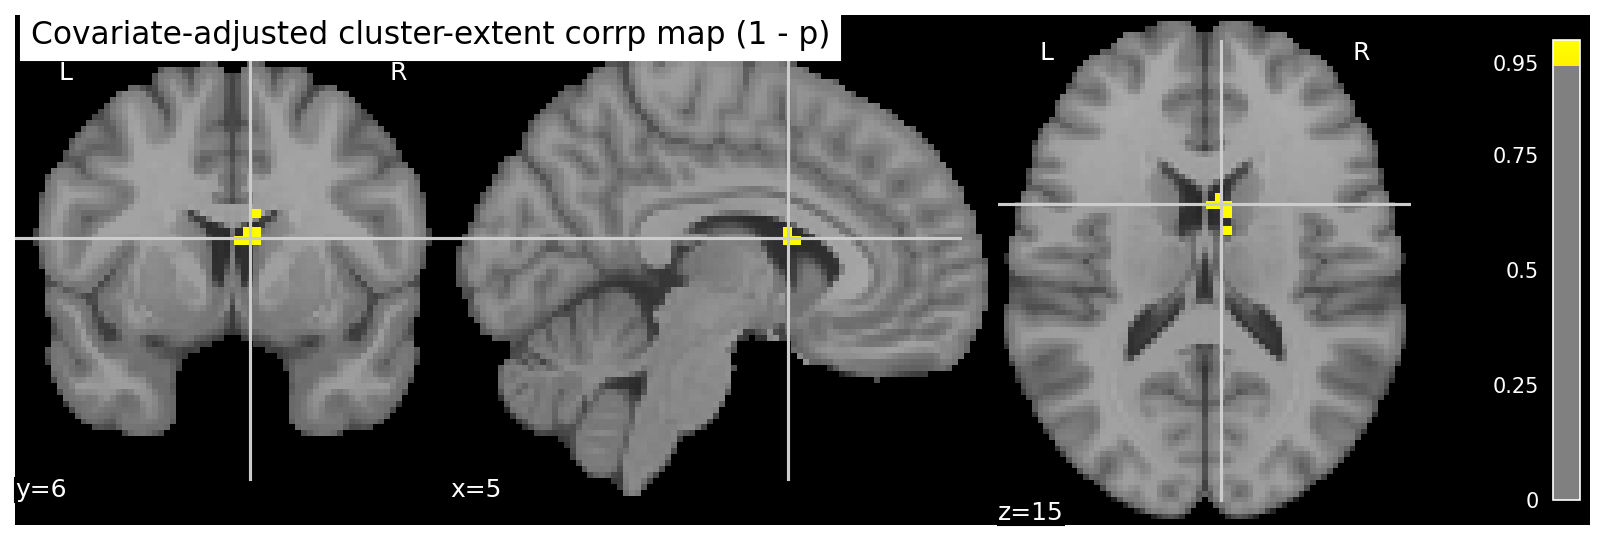

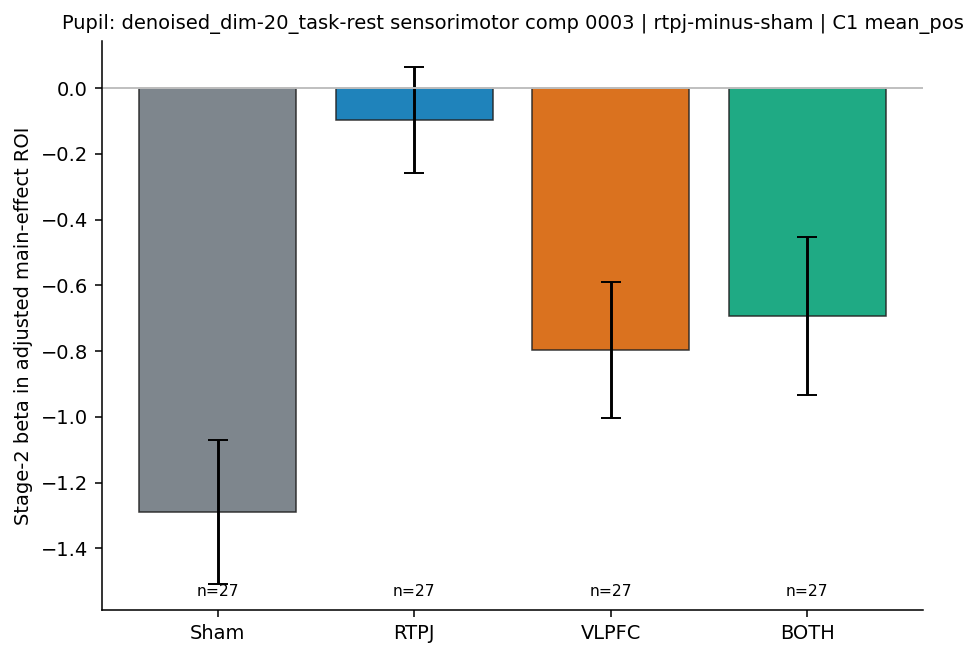

### Blink: smith09_denoised dmn comp 0004 | rtpj-minus-vlpfc | C2 mean_neg

Covariate-adjusted brain map: `derivatives/fsl/covariate_randomise_summary/task-rest_space-MNI152NLin6Asym_desc-Smith09DenoisedCovFdmeanBlinkDmnComp0004RtpjMinusVlpfcMeanNegClusterExtentCorrp_stat-corrp_statmap.nii.gz`    
Threshold: `1-p > 0.95`; voxels shown: **16**.

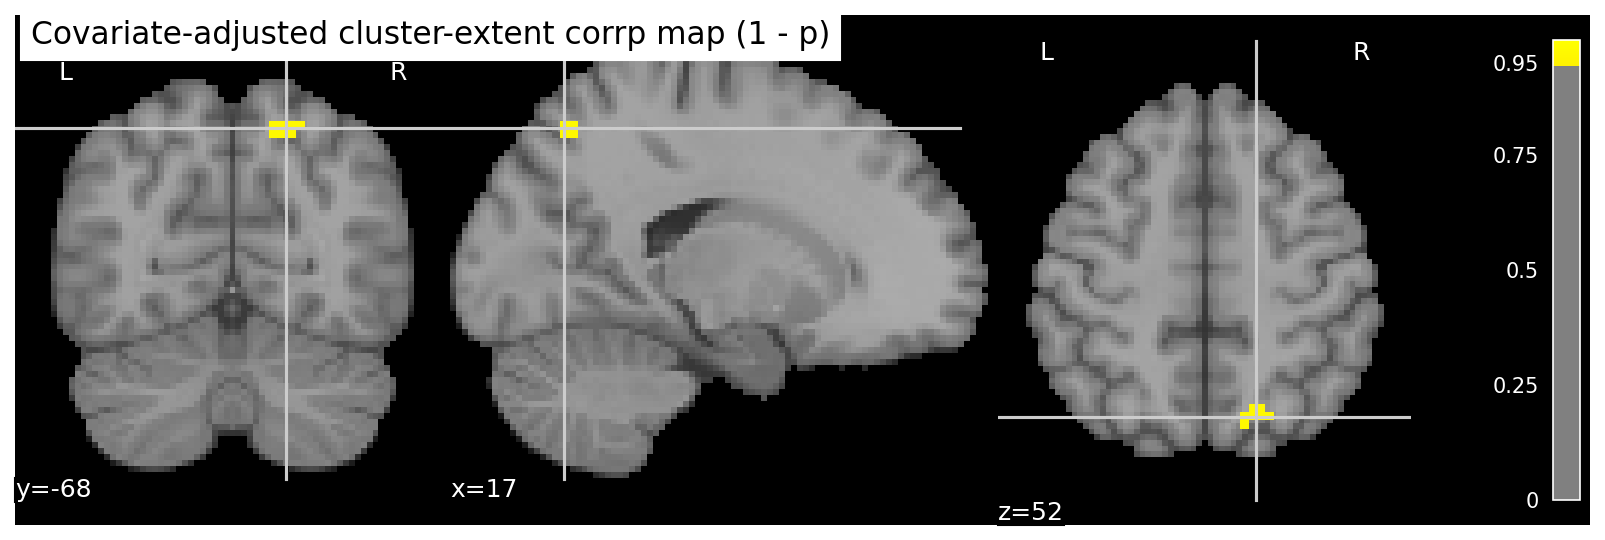

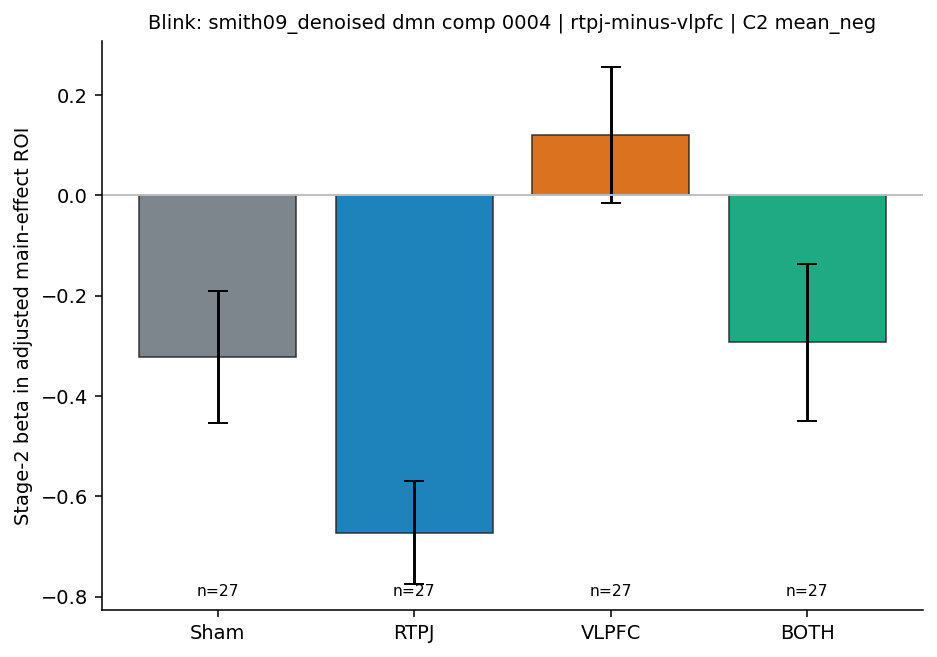

### Blink: denoised_dim-20_task-rest sensorimotor comp 0003 | rtpj-minus-sham | C1 mean_pos

Covariate-adjusted brain map: `derivatives/fsl/covariate_randomise_summary/task-rest_space-MNI152NLin6Asym_desc-DenoisedDim20TaskRestCovFdmeanBlinkSensorimotorComp0003RtpjMinusShamMeanPosClusterExtentCorrp_stat-corrp_statmap.nii.gz`    
Threshold: `1-p > 0.95`; voxels shown: **12**.

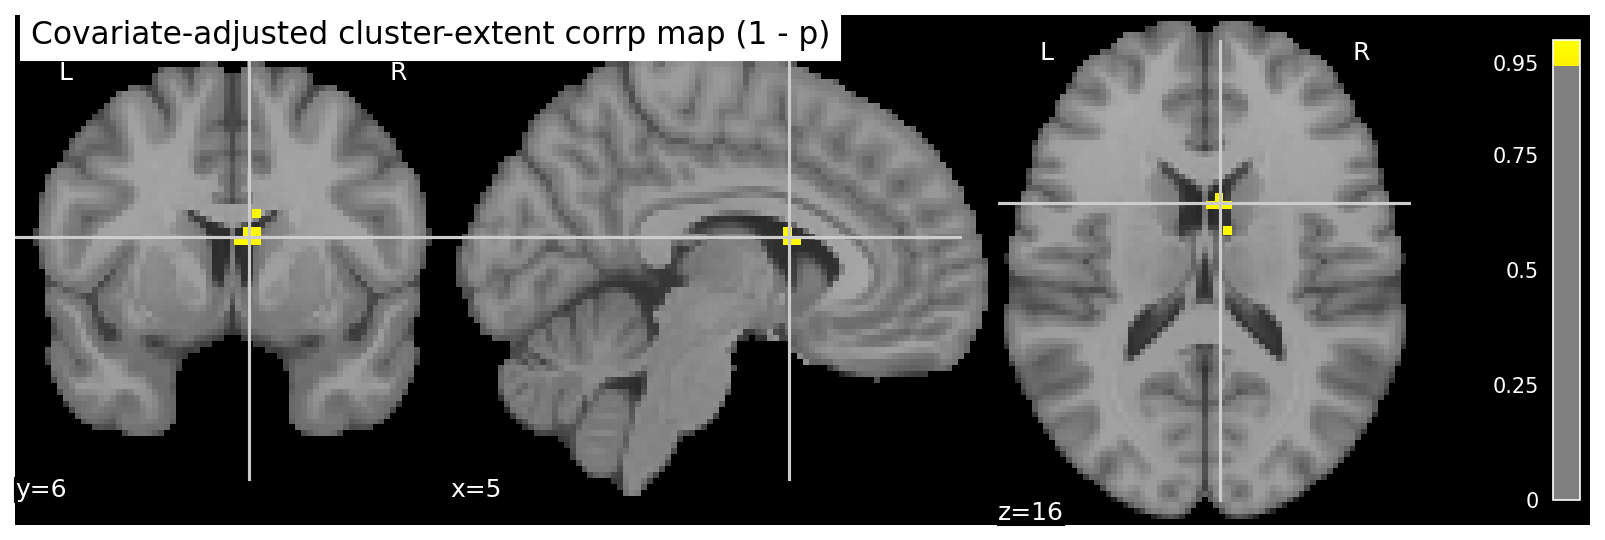

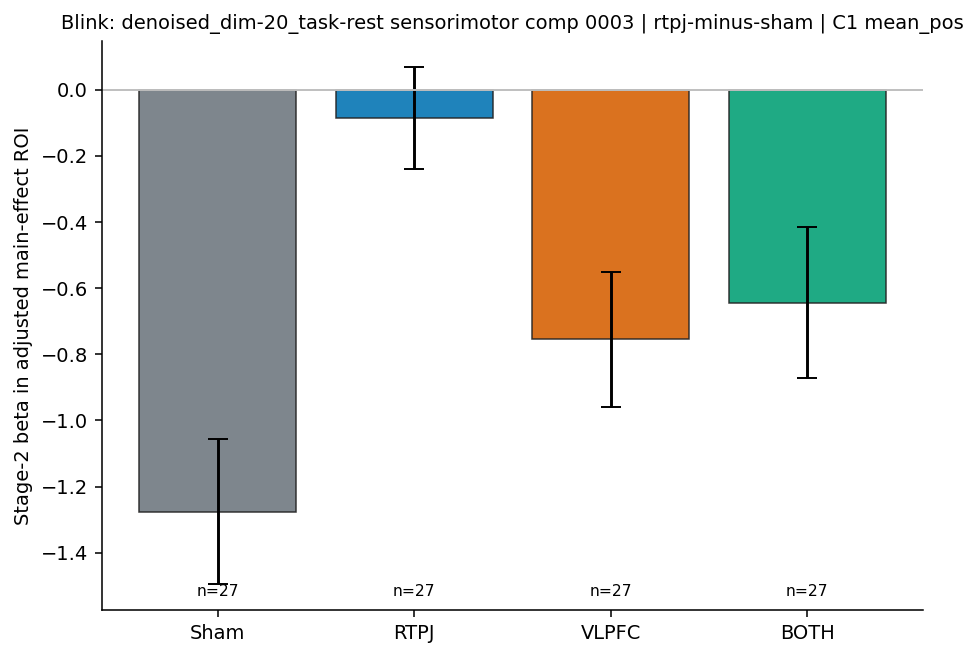

### Pupil: denoised_dim-20_task-rest primary-visual-lateral-visual comp 0006 | both-minus-vlpfc | C1 mean_pos

Covariate-adjusted brain map: `derivatives/fsl/covariate_randomise_summary/task-rest_space-MNI152NLin6Asym_desc-DenoisedDim20TaskRestCovFdmeanPupilPrimaryVisualLateralVisualComp0006BothMinusVlpfcMeanPosClusterExtentCorrp_stat-corrp_statmap.nii.gz`    
Threshold: `1-p > 0.95`; voxels shown: **11**.

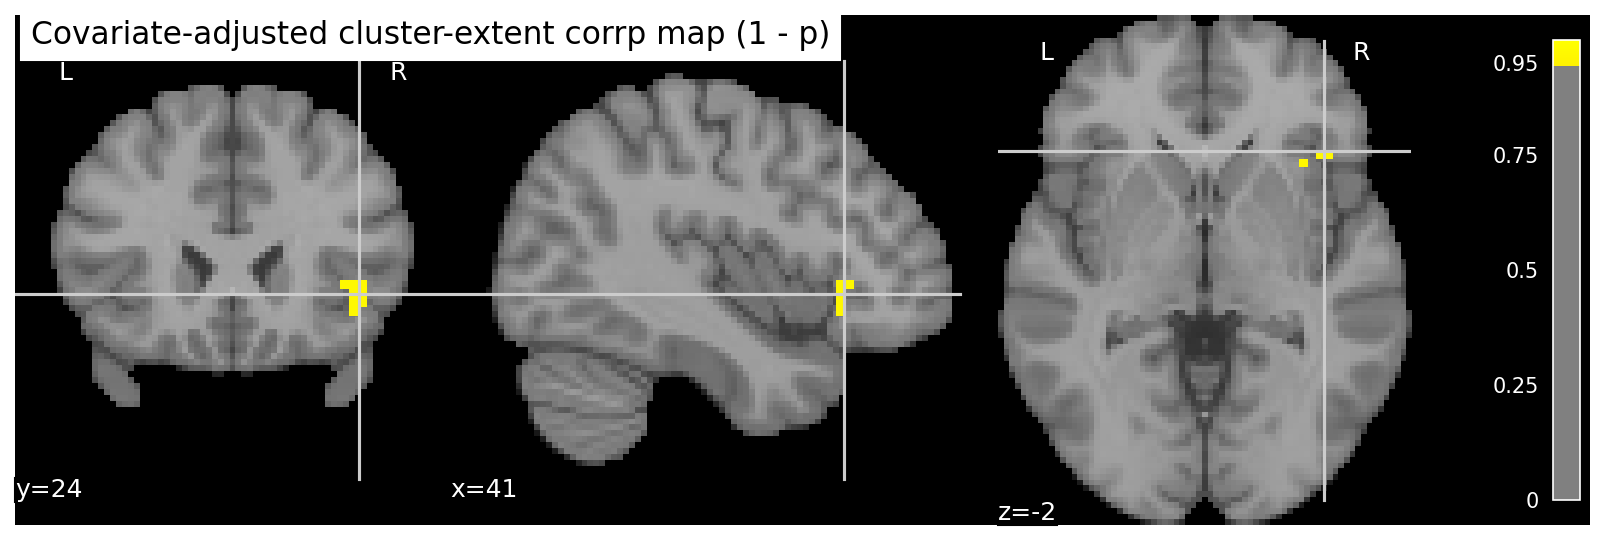

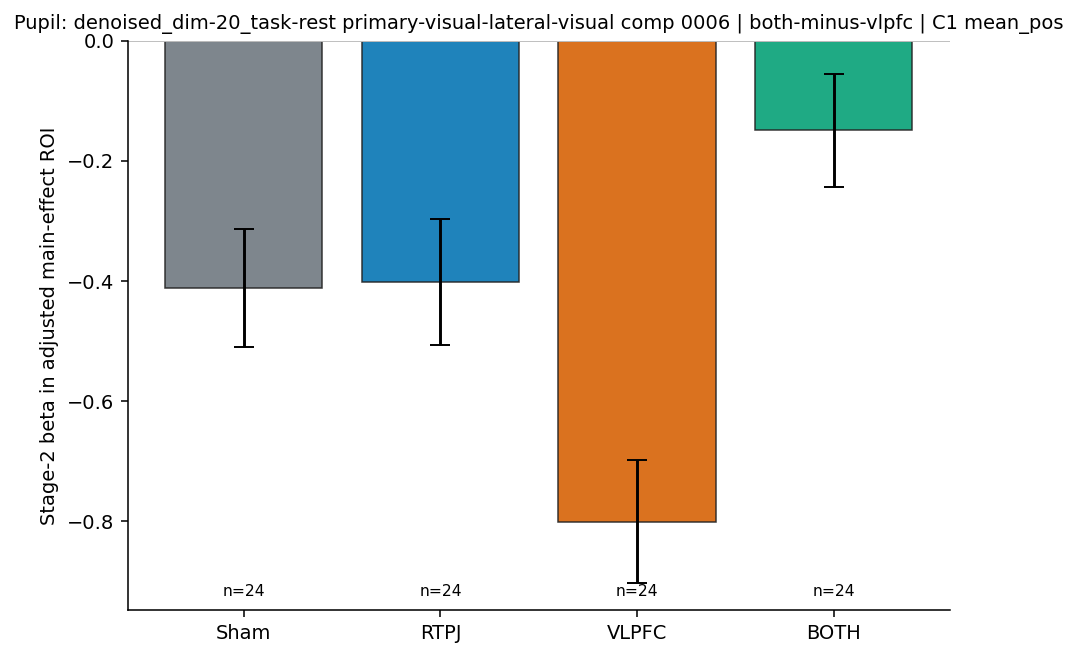

### Pupil: denoised_dim-00_task-rest sensorimotor comp 0022 | vlpfc-minus-sham | C1 mean_pos

Covariate-adjusted brain map: `derivatives/fsl/covariate_randomise_summary/task-rest_space-MNI152NLin6Asym_desc-DenoisedDim00TaskRestCovFdmeanPupilSensorimotorComp0022VlpfcMinusShamMeanPosClusterExtentCorrp_stat-corrp_statmap.nii.gz`    
Threshold: `1-p > 0.95`; voxels shown: **8**.

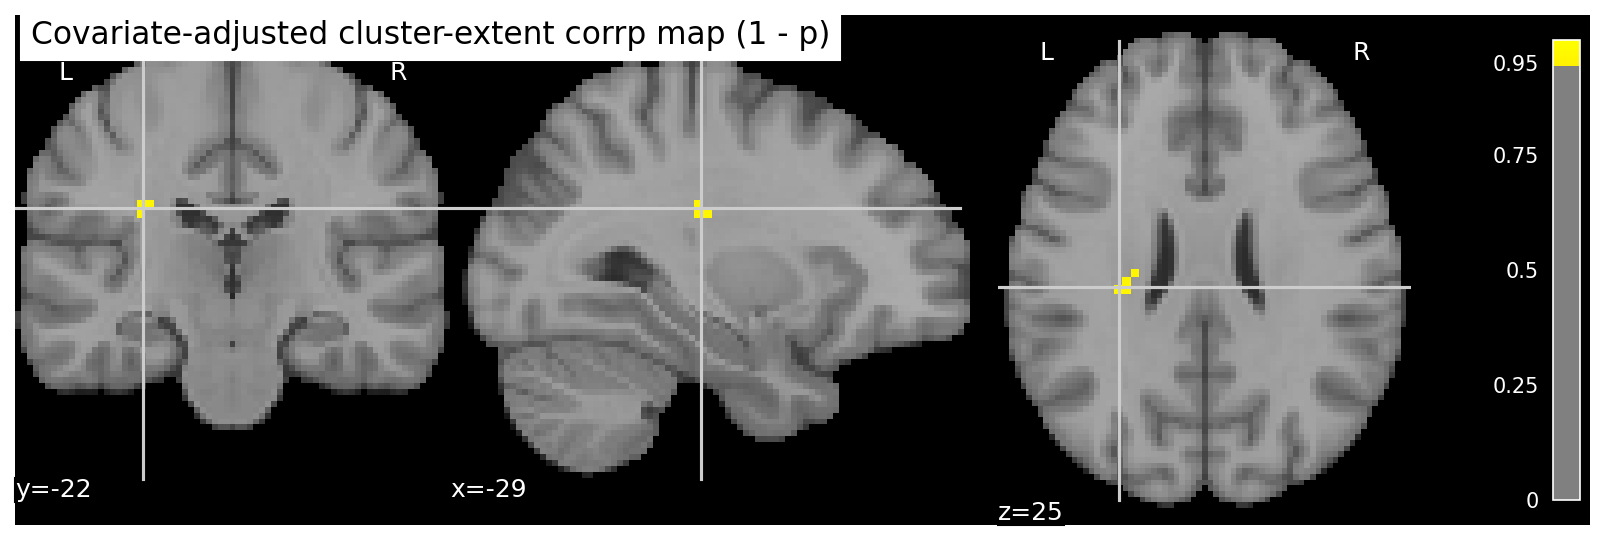

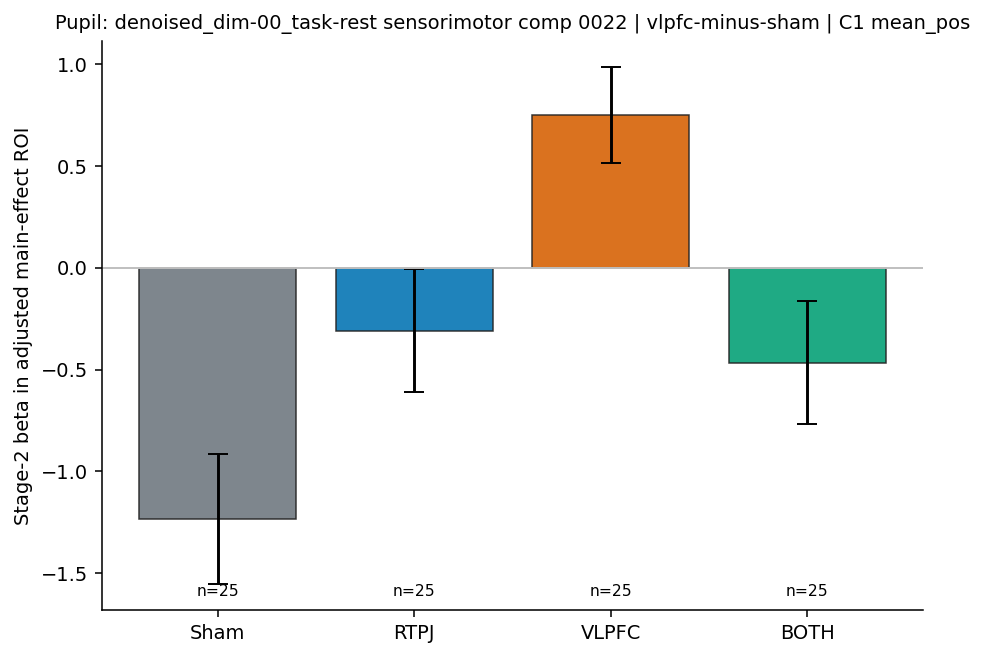

### Pupil: denoised_dim-00_task-rest dmn comp 0023 | rtpj-minus-vlpfc | C2 mean_neg

Covariate-adjusted brain map: `derivatives/fsl/covariate_randomise_summary/task-rest_space-MNI152NLin6Asym_desc-DenoisedDim00TaskRestCovFdmeanPupilDmnComp0023RtpjMinusVlpfcMeanNegClusterExtentCorrp_stat-corrp_statmap.nii.gz`    
Threshold: `1-p > 0.95`; voxels shown: **8**.

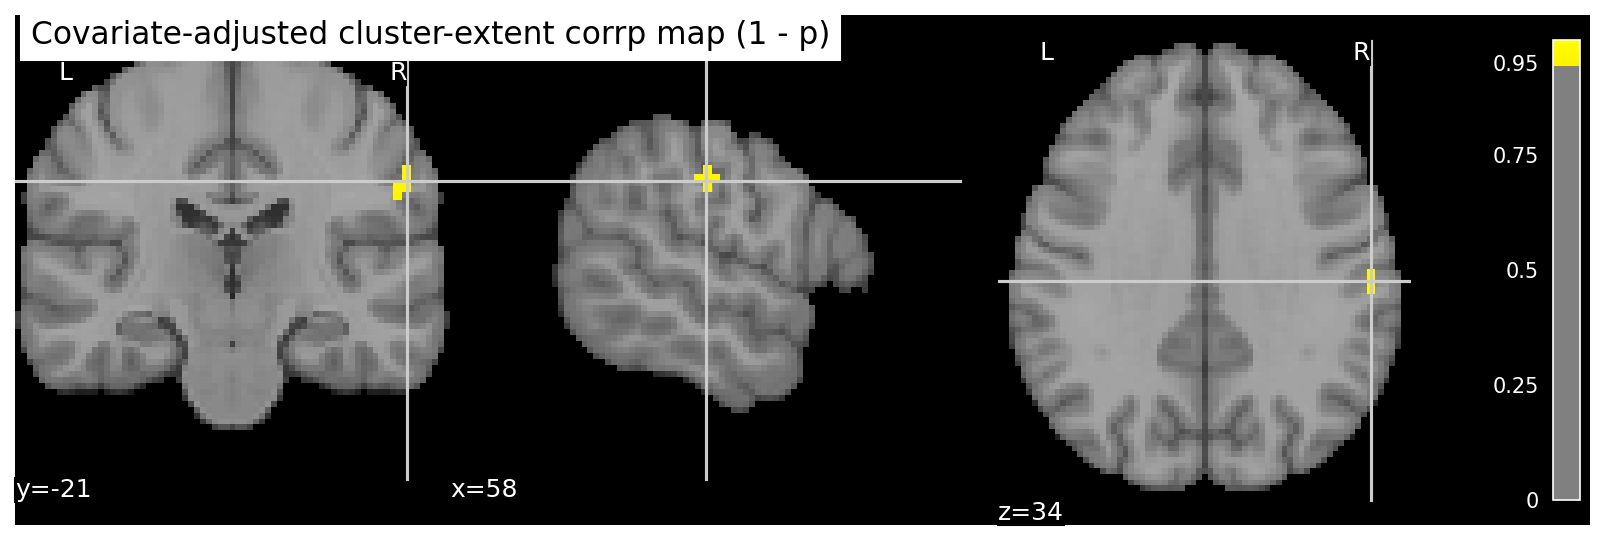

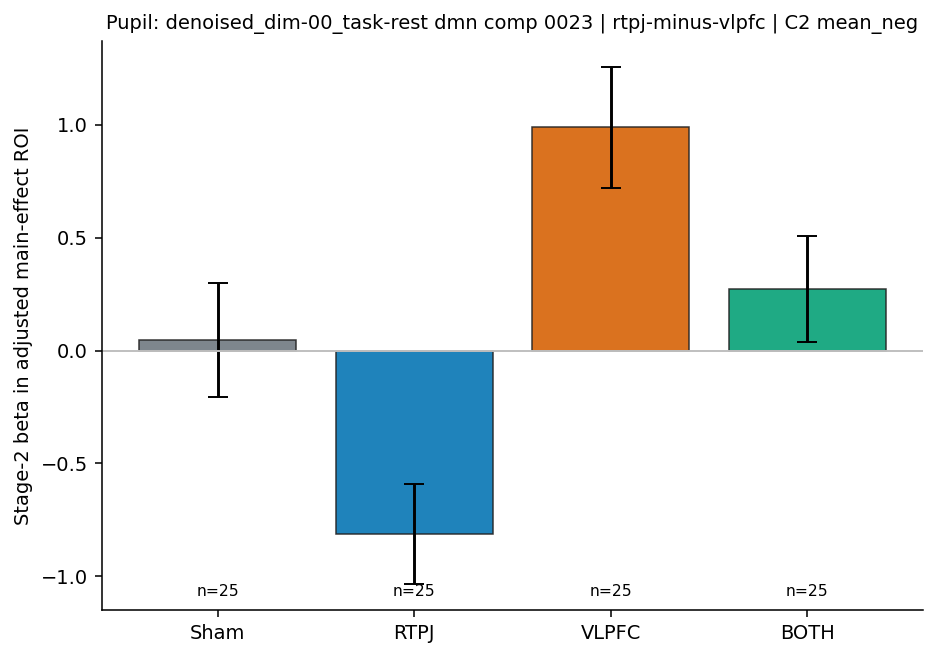

### Blink: smith09_denoised lateral-visual comp 0003 | rtpj-minus-vlpfc | C2 mean_neg

Covariate-adjusted brain map: `derivatives/fsl/covariate_randomise_summary/task-rest_space-MNI152NLin6Asym_desc-Smith09DenoisedCovFdmeanBlinkLateralVisualComp0003RtpjMinusVlpfcMeanNegClusterExtentCorrp_stat-corrp_statmap.nii.gz`    
Threshold: `1-p > 0.95`; voxels shown: **13**.

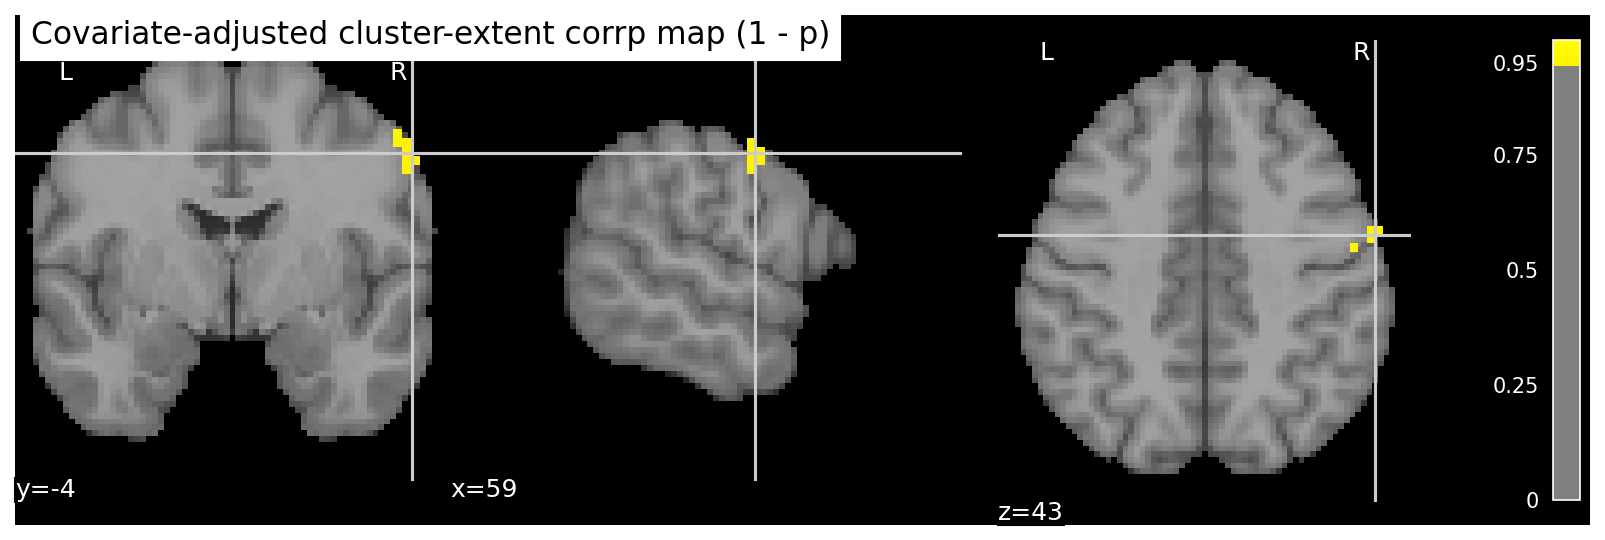

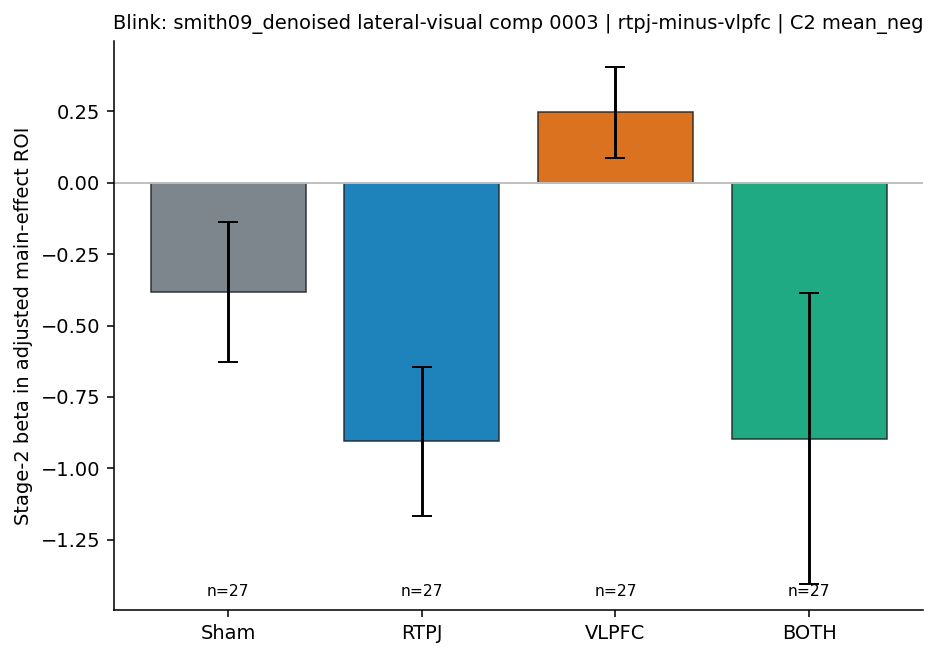

In [6]:
CONDITION_ORDER = ['sham', 'rtpj', 'vlpfc', 'both']
CONDITION_LABELS = {'sham': 'Sham', 'rtpj': 'RTPJ', 'vlpfc': 'VLPFC', 'both': 'BOTH'}
CONDITION_COLORS = {'sham': '#6c757d', 'rtpj': '#0072B2', 'vlpfc': '#D55E00', 'both': '#009E73'}
MNI_TEMPLATE = datasets.load_mni152_template(resolution=2)

robust_keys = set(robustness['main_key'])
main_bar_rows = main_rows[
    main_rows['main_key'].isin(robust_keys)
    & main_rows['condition_values_tsv'].str.strip().ne('')
].copy()

if main_bar_rows.empty:
    display(Markdown(
        '**No C1/C2 condition bar plots are available yet.** Re-run '
        '`python3 code/check_covariate_randomise_results.py --fail-on-missing` on the Linux box after pulling the compiler update. '
        'That will add `condition_values_tsv` entries for significant C1/C2 maps.'
    ))
else:
    display(Markdown(f'Found **{len(main_bar_rows)}** covariate-adjusted C1/C2 condition-value tables linked to the original significant set.'))
    display(main_bar_rows[[
        'model_label', 'analysis', 'network', 'component', 'condition_contrast',
        'design_contrast', 'contrast_name', 'peak_corrp', 'expected_participants',
        'copied_image', 'condition_values_tsv'
    ]].sort_values('peak_corrp', ascending=False))


def covariate_result_image(row):
    source = str(row.get('copied_image', '')).strip() or str(row.get('corrp_file', '')).strip()
    path = project_path(source)
    if not path.is_file():
        raise FileNotFoundError(path)
    return path


def thresholded_covariate_image(row):
    corrp_path = covariate_result_image(row)
    corrp_img = nib.load(str(corrp_path))
    corrp_data = np.asarray(corrp_img.dataobj)
    roi = np.isfinite(corrp_data) & (corrp_data > CORRP_THRESHOLD)
    if not roi.any():
        raise ValueError(f'{corrp_path} has no voxels above {CORRP_THRESHOLD}')
    thresholded = image.new_img_like(corrp_img, np.where(roi, corrp_data, 0.0), copy_header=True)
    try:
        cut_coords = plotting.find_xyz_cut_coords(thresholded)
    except Exception:
        cut_coords = None
    return corrp_path, thresholded, int(roi.sum()), cut_coords


def display_covariate_brain(row):
    corrp_path, thresholded, n_voxels, cut_coords = thresholded_covariate_image(row)
    display(Markdown(
        f'Covariate-adjusted brain map: `{corrp_path.relative_to(PROJECT_ROOT)}`  '
        f'  \nThreshold: `1-p > {CORRP_THRESHOLD}`; voxels shown: **{n_voxels:,}**.'
    ))
    fig = plt.figure(figsize=(10.5, 3.4))
    brain_display = plotting.plot_stat_map(
        thresholded,
        bg_img=MNI_TEMPLATE,
        threshold=CORRP_THRESHOLD,
        display_mode='ortho',
        cut_coords=cut_coords,
        cmap='autumn',
        colorbar=True,
        vmax=1.0,
        figure=fig,
        title='Covariate-adjusted cluster-extent corrp map (1 - p)',
    )
    display_figure(fig, dpi=150)
    brain_display.close()


def plot_condition_bars(row):
    values_path = project_path(row['condition_values_tsv'])
    values = pd.read_csv(values_path, sep='	', dtype=str, keep_default_na=False)
    values['condition'] = values['condition'].str.lower()
    values['stage2_beta'] = pd.to_numeric(values['stage2_beta'], errors='coerce')
    values = values.dropna(subset=['condition', 'stage2_beta']).copy()
    counts = values.groupby('participant')['condition'].nunique()
    if counts.empty or (counts != len(CONDITION_ORDER)).any():
        raise ValueError(f'{values_path} does not have all four conditions for every participant')

    values['condition'] = pd.Categorical(values['condition'], CONDITION_ORDER, ordered=True)
    summary_table = values.groupby('condition', observed=False)['stage2_beta'].agg(['mean', 'sem', 'count']).reindex(CONDITION_ORDER)
    positions = np.arange(len(CONDITION_ORDER))
    fig, ax = plt.subplots(figsize=(6.8, 4.8))
    ax.bar(
        positions,
        summary_table['mean'],
        yerr=summary_table['sem'],
        capsize=5,
        color=[CONDITION_COLORS[item] for item in CONDITION_ORDER],
        edgecolor='#222222',
        linewidth=0.8,
        alpha=0.88,
    )
    ax.axhline(0, color='0.75', linewidth=1)
    ax.set_xticks(positions)
    ax.set_xticklabels([CONDITION_LABELS[item] for item in CONDITION_ORDER])
    ax.set_ylabel('Stage-2 beta in adjusted main-effect ROI')
    ax.set_title(describe_row(row), fontsize=10)
    for xpos, item in zip(positions, CONDITION_ORDER):
        count = int(summary_table.loc[item, 'count'])
        ax.text(xpos, 0.02, f'n={count}', transform=ax.get_xaxis_transform(), ha='center', va='bottom', fontsize=8)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)
    plt.tight_layout()
    display_figure(fig)

for _, row in main_bar_rows.sort_values('peak_corrp_num', ascending=False).iterrows():
    display(Markdown(f"### {describe_row(row)}"))
    display_covariate_brain(row)
    plot_condition_bars(row)


## 7. Covariate model integrity checks

The peak summary confirms that all randomise outputs completed, but the deeper assumptions require the Linux-side model folders. Run `python3 code/check_covariate_model_integrity.py --fail-on-error` on the Linux box and commit the resulting integrity TSV. This section will then report mask size, demeaning, design/audit agreement, subject order, image-list order, and C3/C4 contrast-vector checks.

In [7]:
integrity_path = PROJECT_ROOT / 'derivatives' / 'fsl' / 'covariate_randomise_summary' / 'task-rest_covariate-randomise_integrity.tsv'

summary_check_rows = []
for label, series in {
    'all status ok': summary['status'].eq('ok'),
    'all design.con valid': summary['design_con_valid'].eq('true'),
    'all group inputs complete': summary['group_input_complete'].eq('true'),
    'all completion markers present': summary['completion_marker_exists'].eq('true'),
    'all t-stat files present': summary['tstat_exists'].eq('true'),
    'all corrp files present': summary['corrp_exists'].eq('true'),
}.items():
    summary_check_rows.append({'check': label, 'passed': bool(series.all()), 'n_passed': int(series.sum()), 'n_total': len(series)})
display(pd.DataFrame(summary_check_rows))

if integrity_path.is_file():
    integrity = pd.read_csv(integrity_path, sep='\t', dtype=str, keep_default_na=False)
    bool_columns = [
        'group_input_complete', 'mask_exists', 'design_con_valid', 'intercept_all_ones',
        'covariate_columns_demeaned', 'design_matches_covariate_audit',
        'subject_order_matches_audit', 'image_list_matches_audit', 'c3_c4_test_last_covariate', 'complete'
    ]
    integrity_summary = []
    for column in bool_columns:
        passed = integrity[column].eq('true')
        integrity_summary.append({'check': column, 'n_passed': int(passed.sum()), 'n_total': len(integrity), 'all_passed': bool(passed.all())})
    display(Markdown(f'Loaded integrity audit with **{len(integrity)}** rows.'))
    display(pd.DataFrame(integrity_summary))
    if 'mask_voxels' in integrity:
        mask_values = pd.to_numeric(integrity['mask_voxels'], errors='coerce').dropna()
        if len(mask_values):
            display(Markdown(f'Mask voxel range: **{int(mask_values.min())} - {int(mask_values.max())}**.'))
    problems = integrity[integrity['complete'].ne('true')]
    if problems.empty:
        display(Markdown('All covariate model integrity checks passed.'))
    else:
        display(Markdown('Integrity rows needing review:'))
        display(problems)
else:
    display(Markdown(
        'No tracked integrity TSV found yet. On Linux, run:\n\n'
        '`python3 code/check_covariate_model_integrity.py --fail-on-error`\n\n'
        'Then commit `derivatives/fsl/covariate_randomise_summary/task-rest_covariate-randomise_integrity.tsv`.'
    ))


,check,passed,n_passed,n_total
0,all status ok,True,96,96
1,all design.con valid,True,96,96
2,all group inputs complete,True,96,96
3,all completion markers present,True,96,96
4,all t-stat files present,True,96,96
5,all corrp files present,True,96,96


Loaded integrity audit with **24** rows.

,check,n_passed,n_total,all_passed
0,group_input_complete,24,24,True
1,mask_exists,24,24,True
2,design_con_valid,24,24,True
3,intercept_all_ones,24,24,True
4,covariate_columns_demeaned,24,24,True
5,design_matches_covariate_audit,24,24,True
6,subject_order_matches_audit,24,24,True
7,image_list_matches_audit,24,24,True
8,c3_c4_test_last_covariate,24,24,True
9,complete,24,24,True


Mask voxel range: **39460 - 39460**.

All covariate model integrity checks passed.